In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Check the contents of your Google Drive
drive_path = "/content/drive/MyDrive"

print("Files in MyDrive:")
for item in os.listdir(drive_path):
    print(item)

Files in MyDrive:
KK25
madhu - Page 1.pdf
madhu 1.pdf
madhu 2.pdf
Photo from Madhumita Das
EXAM FORM NOTICE.pdf
Classroom
madhumita.jpg
[John_B_Conway]_Functions_of_one_complex_variable(BookFi) (1).djvu
ConfirmationPage_201610128971.pdf
madhu Wisc picture .jpg
madhu wbsc signature .jpg
isi_jrf_math
madhuclearence.pdf Delhi university .pdf
Motu_msc_markssheet.PDF
madhumita_sc_certificte_corp.pdf
motu1 photo .jpeg
Madhumita_msc_marksheet (1).pdf
Madhumita_msc_marksheet.pdf
madhumita_bsc_marksheet.pdf
ID cards
madhumita_bsc_certificate.pdf
net_june_2023_combined.pdf
combined_madhumita_class_10_certificate_markssheet.pdf
combined_madhumita_class_12_certificate_markssheet.pdf
madhumita phd application documents
madhumita aadhar self attested.jpeg
madhumita bsc degree marks sheet self attedted copy.pdf
madhumita msc marks sheet self attested (1).jpeg
madhumita msc marks sheet self attested.jpeg
madhumita net score card self attested.jpeg
madhumita_cast.jpg
Madhumita_cal_univ_application.jpg


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/projects/medical_image/medical_image.zip"
extract_path = "/content/chest_xray"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Files/folders:")
print(os.listdir(extract_path))

Dataset extracted successfully!
Files/folders:
['sample_labels.csv', 'sample']


Inspect the extracted dataset

In [ ]:
import os

print("Extracted dataset location:")
print(extract_path)

print("\nContents:")
for item in os.listdir(extract_path):
    print(item)

Extracted dataset location:
/content/chest_xray

Contents:
sample_labels.csv
sample


In [ ]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for file in files[:10]:
            print(f"{indent}    {file}")

chest_xray/
    sample_labels.csv
    sample/
        sample_labels.csv
        sample/
            images/
        images/


Find the actual images and CSV files

In [ ]:

import os

for root, dirs, files in os.walk("/content/chest_xray"):
    image_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    csv_files = [
        f for f in files
        if f.lower().endswith(".csv")
    ]

    if image_files or csv_files:
        print("\nFolder:", root)

        if image_files:
            print("Images:", len(image_files))
            print("Example images:", image_files[:5])

        if csv_files:
            print("CSV files:", csv_files)


Folder: /content/chest_xray
CSV files: ['sample_labels.csv']

Folder: /content/chest_xray/sample
CSV files: ['sample_labels.csv']

Folder: /content/chest_xray/sample/sample/images
Images: 5606
Example images: ['00018419_001.png', '00008573_000.png', '00023738_000.png', '00028000_000.png', '00014242_000.png']

Folder: /content/chest_xray/sample/images
Images: 5606
Example images: ['00018419_001.png', '00008573_000.png', '00023738_000.png', '00028000_000.png', '00014242_000.png']


Load the *labels*

In [ ]:
import pandas as pd
import os

# Paths
image_dir = "/content/chest_xray/sample/images"
labels_path = "/content/chest_xray/sample/sample_labels.csv"

# Load labels
df = pd.read_csv(labels_path)

print("Dataset loaded successfully!")
print("Number of rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Number of rows: 5606

Columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']

First 5 rows:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


 Check images and labels

In [ ]:
# Check whether every CSV image exists in the image folder

image_files = set(os.listdir(image_dir))
csv_images = set(df["Image Index"])

# Images listed in CSV but missing from folder
missing_images = csv_images - image_files

# Images in folder but not listed in CSV
extra_images = image_files - csv_images

print("Images listed in CSV:", len(csv_images))
print("Images found in folder:", len(image_files))
print("Missing images:", len(missing_images))
print("Extra images:", len(extra_images))

if len(missing_images) == 0:
    print("\n✅ All labeled images are available.")
else:
    print("\n⚠️ Some images are missing.")
    print("Examples:", list(missing_images)[:10])

Images listed in CSV: 5606
Images found in folder: 5606
Missing images: 0
Extra images: 0

✅ All labeled images are available.


Find all diseases

In [ ]:
# Extract individual disease labels

all_labels = []

for labels in df["Finding Labels"]:
    all_labels.extend(labels.split("|"))

unique_labels = sorted(set(all_labels))

print("Number of unique labels:", len(unique_labels))
print("\nDisease labels:")

for i, label in enumerate(unique_labels, 1):
    print(f"{i}. {label}")

Number of unique labels: 15

Disease labels:
1. Atelectasis
2. Cardiomegaly
3. Consolidation
4. Edema
5. Effusion
6. Emphysema
7. Fibrosis
8. Hernia
9. Infiltration
10. Mass
11. No Finding
12. Nodule
13. Pleural_Thickening
14. Pneumonia
15. Pneumothorax


Disease distribution

In [ ]:
from collections import Counter

# Count how many times each label appears
label_counts = Counter()

for labels in df["Finding Labels"]:
    for label in labels.split("|"):
        label_counts[label] += 1

# Convert to DataFrame
label_distribution = pd.DataFrame(
    label_counts.items(),
    columns=["Disease", "Count"]
).sort_values("Count", ascending=False)

display(label_distribution)

,Disease,Count
5,No Finding,3044
1,Infiltration,967
8,Effusion,644
6,Atelectasis,508
11,Nodule,313
10,Mass,284
3,Pneumothorax,271
9,Consolidation,226
2,Pleural_Thickening,176
4,Cardiomegaly,141


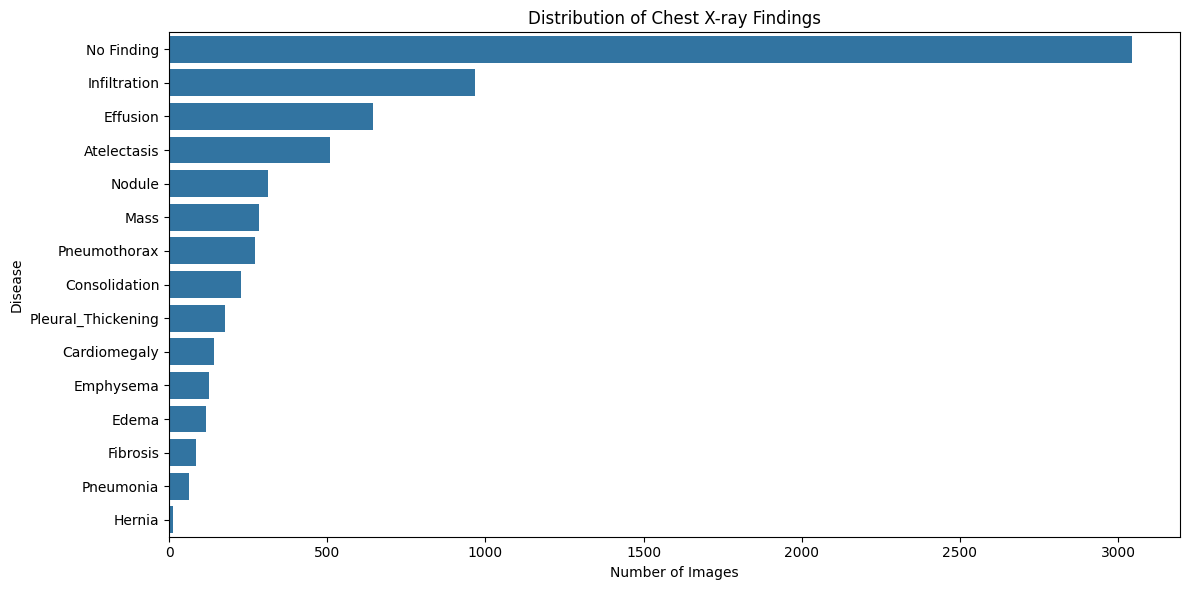

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=label_distribution,
    x="Count",
    y="Disease"
)

plt.title("Distribution of Chest X-ray Findings")
plt.xlabel("Number of Images")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

Single vs Multiple Diseases

In [ ]:
# Count the number of findings for each X-ray

df["Num_Findings"] = df["Finding Labels"].apply(
    lambda x: len(x.split("|"))
)

finding_counts = df["Num_Findings"].value_counts().sort_index()

print("Number of findings per X-ray:")
display(finding_counts.to_frame("Number of Images"))

Number of findings per X-ray:


,Number of Images
Num_Findings,
1,4626
2,690
3,212
4,58
5,17
6,2
7,1


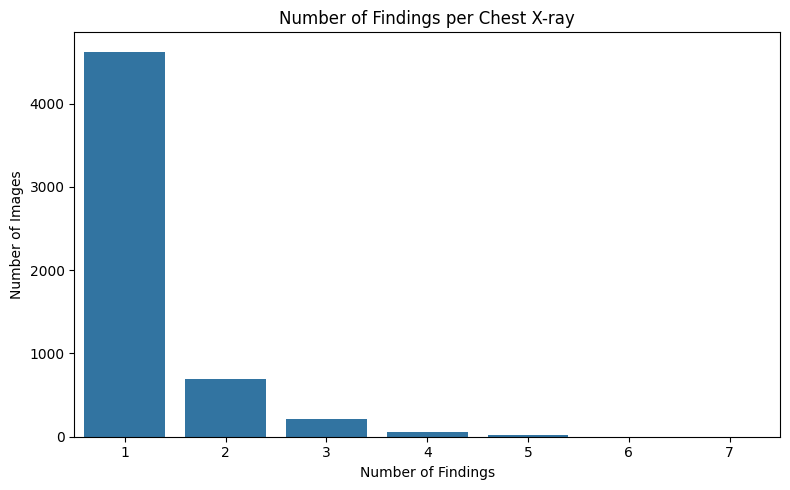

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=finding_counts.index,
    y=finding_counts.values
)

plt.title("Number of Findings per Chest X-ray")
plt.xlabel("Number of Findings")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

Patient-level analysis

In [ ]:
# Patient-level analysis

print("Total X-rays:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

images_per_patient = df.groupby("Patient ID").size()

print("\nImages per patient:")
print(images_per_patient.describe())

print("\nPatients with more than one X-ray:",
      (images_per_patient > 1).sum())

Total X-rays: 5606
Unique patients: 4230

Images per patient:
count    4230.000000
mean        1.325296
std         0.852076
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
dtype: float64

Patients with more than one X-ray: 830


view actual x_ray

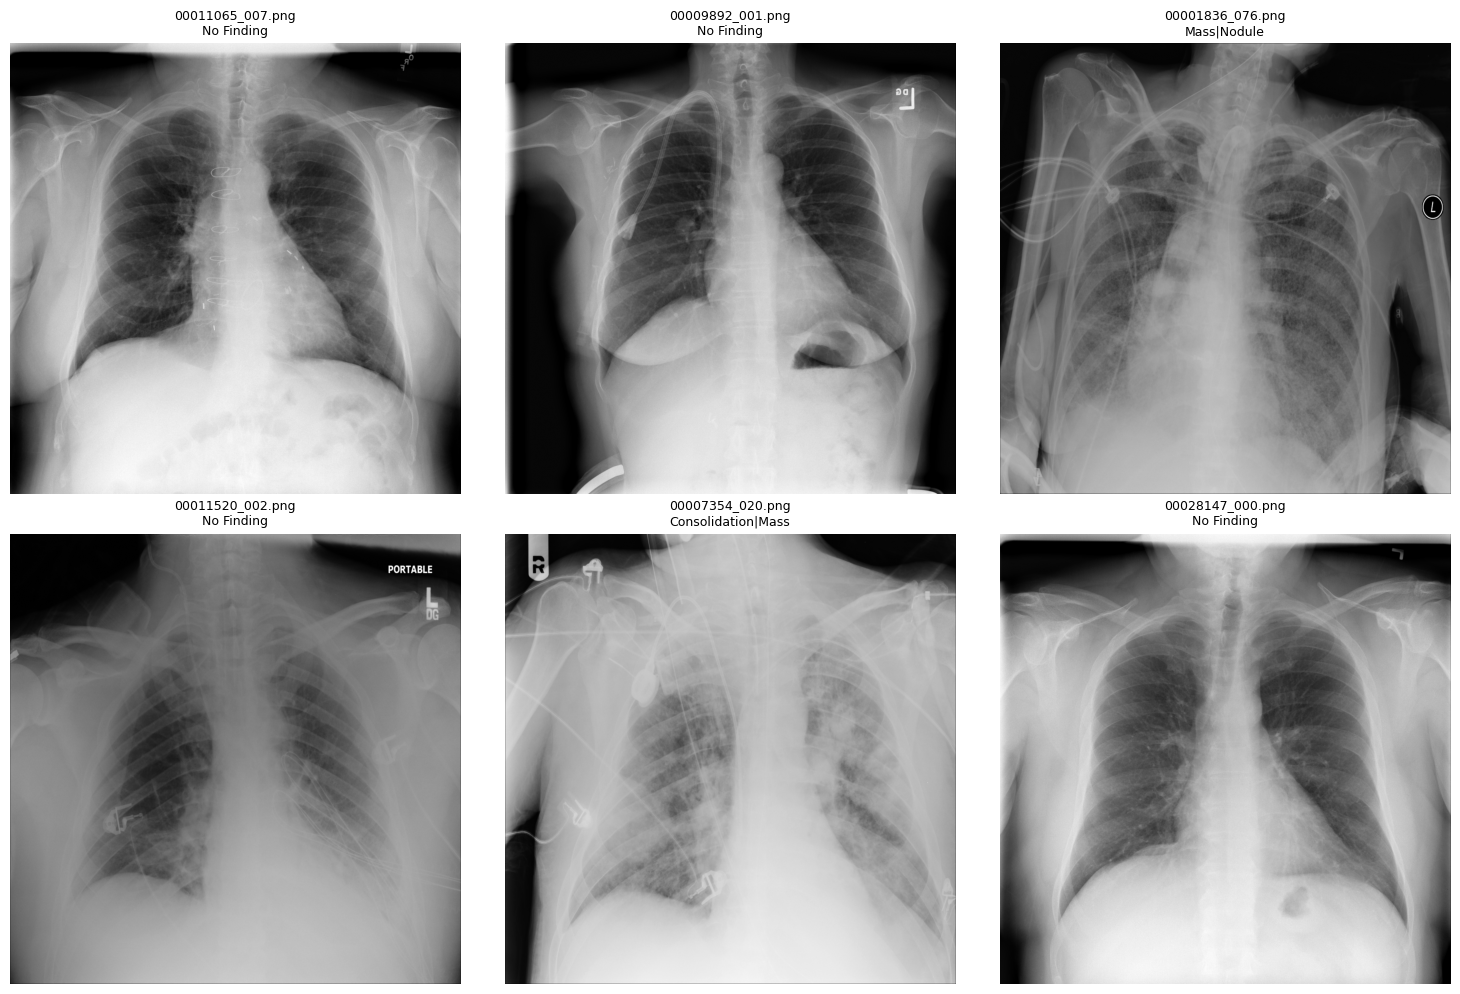

In [ ]:
# Display sample chest X-rays

sample_images = df.sample(6, random_state=42)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_images.iterrows()):
    img_path = os.path.join(image_dir, row["Image Index"])
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f'{row["Image Index"]}\n{row["Finding Labels"]}',
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Cheak the properties

In [ ]:
# Inspect image dimensions and format

sample_path = os.path.join(
    image_dir,
    df.iloc[0]["Image Index"]
)

img = Image.open(sample_path)

print("Image filename:", df.iloc[0]["Image Index"])
print("Image size:", img.size)
print("Image mode:", img.mode)
print("Image format:", img.format)

Image filename: 00000013_005.png
Image size: (1024, 1024)
Image mode: L
Image format: PNG


create disease coloumns

In [ ]:
# Create binary columns for the 14 diseases

disease_labels = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

for disease in disease_labels:
    df[disease] = df["Finding Labels"].apply(
        lambda x: 1 if disease in x.split("|") else 0
    )

print("Disease columns created successfully!")

display(df[disease_labels].head())

Disease columns created successfully!


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,0,0,0,0,0,1,0,0,1,0,0,1,0,1
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,1,1,0,0,0,0,0,0,0,0,0


In [ ]:
# Verify "No Finding" consistency

df["Calculated_No_Finding"] = (
    df[disease_labels].sum(axis=1) == 0
)

df["Original_No_Finding"] = df["Finding Labels"].apply(
    lambda x: "No Finding" in x.split("|")
)

print("No Finding consistency check:")
print(
    (df["Calculated_No_Finding"] == df["Original_No_Finding"]).value_counts()
)

inconsistent = df[
    df["Calculated_No_Finding"] != df["Original_No_Finding"]
]

print("\nNumber of inconsistent rows:", len(inconsistent))

No Finding consistency check:
True    5606
Name: count, dtype: int64

Number of inconsistent rows: 0


Patient-level Train/Validation/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Get unique patient IDs
unique_patients = df["Patient ID"].unique()

print("Total unique patients:", len(unique_patients))

# 70% train, 30% temporary
train_patients, temp_patients = train_test_split(
    unique_patients,
    test_size=0.30,
    random_state=42
)

# Split temporary into 15% validation and 15% test
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

# Create datasets
train_df = df[df["Patient ID"].isin(train_patients)].copy()
val_df = df[df["Patient ID"].isin(val_patients)].copy()
test_df = df[df["Patient ID"].isin(test_patients)].copy()

print("\nPatient split:")
print("Training patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))

print("\nImage split:")
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTotal images:", len(train_df) + len(val_df) + len(test_df))

Total unique patients: 4230

Patient split:
Training patients: 2961
Validation patients: 634
Test patients: 635

Image split:
Training images: 3906
Validation images: 846
Test images: 854

Total images: 5606


In [ ]:
# Check for patient overlap between splits

train_patient_set = set(train_df["Patient ID"])
val_patient_set = set(val_df["Patient ID"])
test_patient_set = set(test_df["Patient ID"])

print("Train ∩ Validation:",
      len(train_patient_set & val_patient_set))

print("Train ∩ Test:",
      len(train_patient_set & test_patient_set))

print("Validation ∩ Test:",
      len(val_patient_set & test_patient_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


Check disease distribution across splits


In [ ]:
# Compare disease distribution across train, validation, and test sets

distribution = pd.DataFrame({
    "Disease": disease_labels,
    "Train": [train_df[d].sum() for d in disease_labels],
    "Validation": [val_df[d].sum() for d in disease_labels],
    "Test": [test_df[d].sum() for d in disease_labels]
})

display(distribution)

,Disease,Train,Validation,Test
0,Atelectasis,369,61,78
1,Cardiomegaly,88,20,33
2,Consolidation,158,30,38
3,Edema,74,27,17
4,Effusion,441,94,109
5,Emphysema,73,26,28
6,Fibrosis,58,14,12
7,Hernia,9,1,3
8,Infiltration,658,142,167
9,Mass,196,44,44


In [ ]:
# Percentage of images containing each disease in each split

distribution_pct = distribution.copy()

distribution_pct["Train (%)"] = (
    distribution_pct["Train"] / len(train_df) * 100
)

distribution_pct["Validation (%)"] = (
    distribution_pct["Validation"] / len(val_df) * 100
)

distribution_pct["Test (%)"] = (
    distribution_pct["Test"] / len(test_df) * 100
)

distribution_pct = distribution_pct[
    ["Disease", "Train (%)", "Validation (%)", "Test (%)"]
]

display(distribution_pct.round(2))

,Disease,Train (%),Validation (%),Test (%)
0,Atelectasis,9.45,7.21,9.13
1,Cardiomegaly,2.25,2.36,3.86
2,Consolidation,4.05,3.55,4.45
3,Edema,1.89,3.19,1.99
4,Effusion,11.29,11.11,12.76
5,Emphysema,1.87,3.07,3.28
6,Fibrosis,1.48,1.65,1.41
7,Hernia,0.23,0.12,0.35
8,Infiltration,16.85,16.78,19.56
9,Mass,5.02,5.20,5.15


create the pytroch dataset

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Image size for pretrained models
IMAGE_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transformations
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


Create ChestXrayDataset

In [ ]:
class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        # Image path
        image_path = os.path.join(
            self.image_dir,
            row["Image Index"]
        )

        # Load image as grayscale
        image = Image.open(image_path).convert("L")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Get disease labels
        labels = torch.tensor(
            row[disease_labels].values.astype(float),
            dtype=torch.float32
        )

        return image, labels

Test one X-ray

In [ ]:
# Create a small dataset object

train_dataset = ChestXrayDataset(
    train_df,
    image_dir,
    transform=train_transform
)

# Load the first sample
image, labels = train_dataset[0]

print("Image shape:", image.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)
print("Image data type:", image.dtype)

Image shape: torch.Size([3, 224, 224])
Labels shape: torch.Size([14])
Labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Image data type: torch.float32


Create Validation and Test datasets

In [ ]:
# Create validation and test datasets

val_dataset = ChestXrayDataset(
    val_df,
    image_dir,
    transform=val_test_transform
)

test_dataset = ChestXrayDataset(
    test_df,
    image_dir,
    transform=val_test_transform
)

print("Datasets created successfully!")
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Datasets created successfully!
Training samples: 3906
Validation samples: 846
Test samples: 854


Create DataLoaders

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully!")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully!
Batch size: 32
Training batches: 123
Validation batches: 27
Test batches: 27


Check one training batch


In [ ]:
# Check one batch from the training DataLoader

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

print("\nMinimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 14])
Images dtype: torch.float32
Labels dtype: torch.float32

Minimum pixel value: -2.1179039478302
Maximum pixel value: 2.640000104904175


Calculate class weights

In [ ]:
# Calculate positive weights for each disease
# Used to handle class imbalance

positive_counts = train_df[disease_labels].sum()
negative_counts = len(train_df) - positive_counts

pos_weights = negative_counts / positive_counts

print("Positive weights for each disease:\n")

for disease, weight in zip(disease_labels, pos_weights):
    print(f"{disease:20s}: {weight:.2f}")

Positive weights for each disease:

Atelectasis         : 9.59
Cardiomegaly        : 43.39
Consolidation       : 23.72
Edema               : 51.78
Effusion            : 7.86
Emphysema           : 52.51
Fibrosis            : 66.34
Hernia              : 433.00
Infiltration        : 4.94
Mass                : 18.93
Nodule              : 17.08
Pleural_Thickening  : 29.05
Pneumonia           : 99.15
Pneumothorax        : 20.58


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Training device: cuda
GPU: Tesla T4


buold the baseline CNN

In [ ]:
import torch.nn as nn

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=14):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model
baseline_model = BaselineCNN(num_classes=14)

# Move model to T4 GPU
baseline_model = baseline_model.to(device)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

Create the weighted loss

In [ ]:
# Move class weights to the T4 GPU

pos_weight_tensor = torch.tensor(
    pos_weights.values,
    dtype=torch.float32
).to(device)

# Weighted binary cross-entropy loss
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

print("Loss function created successfully!")
print("Device:", pos_weight_tensor.device)
print("Number of class weights:", len(pos_weight_tensor))

Loss function created successfully!
Device: cuda:0
Number of class weights: 14


In [ ]:
# Create optimizer for the baseline CNN

optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("Optimizer created successfully!")
print("Learning rate:", 1e-3)
print("Weight decay:", 1e-4)

Optimizer created successfully!
Learning rate: 0.001
Weight decay: 0.0001


est one forward pass

In [ ]:
# Test one batch through the baseline CNN

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = baseline_model(images)
    loss = criterion(outputs, labels)

print("Forward pass successful!")
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Test loss:", loss.item())
print("Output device:", outputs.device)

Forward pass successful!
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 14])
Labels shape: torch.Size([32, 14])
Test loss: 1.2695159912109375
Output device: cuda:0


In [ ]:
# Training configuration

NUM_EPOCHS = 10
PATIENCE = 3

best_val_loss = float("inf")
patience_counter = 0

print("Training configuration:")
print("Epochs:", NUM_EPOCHS)
print("Early stopping patience:", PATIENCE)

Training configuration:
Epochs: 10
Early stopping patience: 3


In [ ]:
# Train the baseline CNN

from tqdm.auto import tqdm

train_losses = []
val_losses = []

# Mixed precision for T4 GPU
scaler = torch.amp.GradScaler("cuda")

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    baseline_model.train()

    running_train_loss = 0.0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"
    )

    for images, labels in train_progress:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        with torch.amp.autocast("cuda"):
            outputs = baseline_model(images)
            loss = criterion(outputs, labels)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        train_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    baseline_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = baseline_model(images)
                loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    # -------------------------
    # Save best model
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        patience_counter = 0

        torch.save(
            baseline_model.state_dict(),
            "baseline_cnn_best.pth"
        )

        print("✓ Best model saved!")

    else:

        patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: {patience_counter}/{PATIENCE}"
        )

        if patience_counter >= PATIENCE:

            print("\nEarly stopping triggered.")
            break

print("\nBaseline CNN training completed!")
print("Best validation loss:", best_val_loss)

Epoch 1/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]


Epoch [1/10] Train Loss: 1.4060 Val Loss: 1.3436
✓ Best model saved!


Epoch 2/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]


Epoch [2/10] Train Loss: 1.3192 Val Loss: 1.3278
✓ Best model saved!


Epoch 3/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]

...

Epoch 8/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a08084d6700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a08084d6700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch [8/10] Train Loss: 1.2891 Val Loss: 1.3535
No improvement. Patience: 2/3


Epoch 9/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]


Epoch [9/10] Train Loss: 1.2809 Val Loss: 1.3538
No improvement. Patience: 3/3

Early stopping triggered.

Baseline CNN training completed!
Best validation loss: 1.2932309221338343


In [ ]:
# Load the best baseline CNN checkpoint

baseline_model.load_state_dict(
    torch.load(
        "baseline_cnn_best.pth",
        map_location=device,
        weights_only=True
    )
)

baseline_model = baseline_model.to(device)
baseline_model.eval()

print("Best baseline model loaded successfully!")
print("Best validation loss:", best_val_loss)

Best baseline model loaded successfully!
Best validation loss: 1.2932309221338343


In [ ]:
# Create evaluation DataLoaders without multiprocessing warnings

EVAL_BATCH_SIZE = 32

val_loader_eval = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_eval = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Evaluation DataLoaders created successfully!")
print("Validation batches:", len(val_loader_eval))
print("Test batches:", len(test_loader_eval))

Evaluation DataLoaders created successfully!
Validation batches: 27
Test batches: 27


In [ ]:
# Generate predictions for validation and test sets

def get_predictions(model, loader):

    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in tqdm(loader, desc="Generating predictions"):

            images = images.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)

            # Convert logits to probabilities
            probabilities = torch.sigmoid(outputs)

            all_labels.append(labels.numpy())
            all_probs.append(probabilities.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    return all_labels, all_probs


# Validation predictions
val_labels, val_probs = get_predictions(
    baseline_model,
    val_loader_eval
)

# Test predictions
test_labels, test_probs = get_predictions(
    baseline_model,
    test_loader_eval
)

print("\nPrediction generation completed!")

print("Validation labels shape:", val_labels.shape)
print("Validation probabilities shape:", val_probs.shape)

print("Test labels shape:", test_labels.shape)
print("Test probabilities shape:", test_probs.shape)

print(
    "\nProbability range:",
    test_probs.min(),
    "to",
    test_probs.max()
)

Generating predictions:   0%|          | 0/27 [00:00<?, ?it/s]

Generating predictions:   0%|          | 0/27 [00:00<?, ?it/s]


Prediction generation completed!
Validation labels shape: (846, 14)
Validation probabilities shape: (846, 14)
Test labels shape: (854, 14)
Test probabilities shape: (854, 14)

Probability range: 0.0052 to 0.9497


ROC-AUC evaluation

In [ ]:
from sklearn.metrics import roc_auc_score

print("Baseline CNN - ROC-AUC")
print("=" * 50)

roc_auc_scores = {}

for i, disease in enumerate(disease_labels):

    try:
        score = roc_auc_score(
            test_labels[:, i],
            test_probs[:, i]
        )

        roc_auc_scores[disease] = score

        print(f"{disease:20s}: {score:.4f}")

    except ValueError:
        roc_auc_scores[disease] = np.nan
        print(f"{disease:20s}: Cannot calculate")


# Macro-average ROC-AUC
valid_auc = [
    score for score in roc_auc_scores.values()
    if not np.isnan(score)
]

macro_roc_auc = np.mean(valid_auc)

print("=" * 50)
print(f"Macro ROC-AUC:       {macro_roc_auc:.4f}")

Baseline CNN - ROC-AUC
Atelectasis         : 0.4821
Cardiomegaly        : 0.5197
Consolidation       : 0.6364
Edema               : 0.7167
Effusion            : 0.5441
Emphysema           : 0.4212
Fibrosis            : 0.6394
Hernia              : 0.7767
Infiltration        : 0.5766
Mass                : 0.4648
Nodule              : 0.5547
Pleural_Thickening  : 0.6041
Pneumonia           : 0.6315
Pneumothorax        : 0.5115
Macro ROC-AUC:       0.5771


Average Precision

In [ ]:
from sklearn.metrics import average_precision_score

print("Baseline CNN - Average Precision")
print("=" * 50)

ap_scores = {}

for i, disease in enumerate(disease_labels):

    try:
        score = average_precision_score(
            test_labels[:, i],
            test_probs[:, i]
        )

        ap_scores[disease] = score

        print(f"{disease:20s}: {score:.4f}")

    except ValueError:
        ap_scores[disease] = np.nan
        print(f"{disease:20s}: Cannot calculate")


# Macro-average AP
valid_ap = [
    score for score in ap_scores.values()
    if not np.isnan(score)
]

macro_ap = np.mean(valid_ap)

print("=" * 50)
print(f"Macro Average Precision: {macro_ap:.4f}")

Baseline CNN - Average Precision
Atelectasis         : 0.0881
Cardiomegaly        : 0.0470
Consolidation       : 0.0746
Edema               : 0.0581
Effusion            : 0.1437
Emphysema           : 0.0272
Fibrosis            : 0.0251
Hernia              : 0.0103
Infiltration        : 0.2289
Mass                : 0.0466
Nodule              : 0.0727
Pleural_Thickening  : 0.0576
Pneumonia           : 0.0189
Pneumothorax        : 0.0544
Macro Average Precision: 0.0681


Find optimal thresholds using validation data

In [ ]:
from sklearn.metrics import f1_score

# Find the best F1 threshold for each disease using ONLY validation data

optimal_thresholds = {}

print("Optimal thresholds from validation set")
print("=" * 50)

for i, disease in enumerate(disease_labels):

    best_threshold = 0.5
    best_f1 = 0.0

    # Try thresholds from 0.10 to 0.90
    thresholds = np.arange(0.10, 0.91, 0.05)

    for threshold in thresholds:

        predictions = (
            val_probs[:, i] >= threshold
        ).astype(int)

        score = f1_score(
            val_labels[:, i],
            predictions,
            zero_division=0
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    optimal_thresholds[disease] = best_threshold

    print(
        f"{disease:20s}: "
        f"threshold={best_threshold:.2f}, "
        f"validation F1={best_f1:.4f}"
    )

print("=" * 50)
print("Threshold optimization completed!")

Optimal thresholds from validation set
Atelectasis         : threshold=0.55, validation F1=0.1905
Cardiomegaly        : threshold=0.10, validation F1=0.0462
Consolidation       : threshold=0.65, validation F1=0.1000
Edema               : threshold=0.55, validation F1=0.1183
Effusion            : threshold=0.50, validation F1=0.2025
Emphysema           : threshold=0.45, validation F1=0.0715
Fibrosis            : threshold=0.65, validation F1=0.0583
Hernia              : threshold=0.85, validation F1=0.0800
Infiltration        : threshold=0.55, validation F1=0.3168
Mass                : threshold=0.45, validation F1=0.0994
Nodule              : threshold=0.45, validation F1=0.1171
Pleural_Thickening  : threshold=0.55, validation F1=0.0952
Pneumonia           : threshold=0.60, validation F1=0.0327
Pneumothorax        : threshold=0.50, validation F1=0.1141
Threshold optimization completed!


Final test-set classification metrics

In [ ]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)

# Convert test probabilities to binary predictions
# using thresholds learned from validation data

test_predictions = np.zeros_like(test_probs, dtype=int)

for i, disease in enumerate(disease_labels):

    threshold = optimal_thresholds[disease]

    test_predictions[:, i] = (
        test_probs[:, i] >= threshold
    ).astype(int)


# ---------------------------------------
# Per-disease metrics
# ---------------------------------------

print("Baseline CNN - Test Metrics")
print("=" * 80)

test_f1_scores = {}
test_precision_scores = {}
test_recall_scores = {}

for i, disease in enumerate(disease_labels):

    f1 = f1_score(
        test_labels[:, i],
        test_predictions[:, i],
        zero_division=0
    )

    precision = precision_score(
        test_labels[:, i],
        test_predictions[:, i],
        zero_division=0
    )

    recall = recall_score(
        test_labels[:, i],
        test_predictions[:, i],
        zero_division=0
    )

    test_f1_scores[disease] = f1
    test_precision_scores[disease] = precision
    test_recall_scores[disease] = recall

    print(
        f"{disease:20s} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )


# ---------------------------------------
# Macro averages
# ---------------------------------------

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_precision = precision_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)


# ---------------------------------------
# Micro averages
# ---------------------------------------

micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

micro_precision = precision_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)


print("=" * 80)

print("\nMacro Metrics:")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")

print("\nMicro Metrics:")
print(f"Micro F1:        {micro_f1:.4f}")
print(f"Micro Precision: {micro_precision:.4f}")
print(f"Micro Recall:    {micro_recall:.4f}")

Baseline CNN - Test Metrics
Atelectasis          | F1: 0.0588 | Precision: 0.0543 | Recall: 0.0641
Cardiomegaly         | F1: 0.0744 | Precision: 0.0386 | Recall: 1.0000
Consolidation        | F1: 0.1053 | Precision: 0.1053 | Recall: 0.1053
Edema                | F1: 0.0657 | Precision: 0.0346 | Recall: 0.6471
Effusion             | F1: 0.2357 | Precision: 0.1339 | Recall: 0.9817
Emphysema            | F1: 0.0624 | Precision: 0.0328 | Recall: 0.6429
Fibrosis             | F1: 0.0308 | Precision: 0.0169 | Recall: 0.1667
Hernia               | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Infiltration         | F1: 0.2908 | Precision: 0.2533 | Recall: 0.3413
Mass                 | F1: 0.0949 | Precision: 0.0500 | Recall: 0.9318
Nodule               | F1: 0.1237 | Precision: 0.0669 | Recall: 0.8200
Pleural_Thickening   | F1: 0.0800 | Precision: 0.0800 | Recall: 0.0800
Pneumonia            | F1: 0.0412 | Precision: 0.0213 | Recall: 0.6364
Pneumothorax         | F1: 0.1024 | Precision: 0.

In [ ]:
# ============================================
# Cell 41 - Store Baseline CNN Results
# ============================================

baseline_results = {
    "Model": "Baseline CNN",
    "ROC-AUC": np.mean(list(roc_auc_scores.values())),
    "Average Precision": np.mean(
        [
            average_precision_score(
                test_labels[:, i],
                test_probs[:, i]
            )
            for i in range(len(disease_labels))
        ]
    ),
    "Macro F1": macro_f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Micro F1": micro_f1,
    "Micro Precision": micro_precision,
    "Micro Recall": micro_recall
}

baseline_results_df = pd.DataFrame([baseline_results])

print("Baseline CNN Results")
print("=" * 80)
print(baseline_results_df.to_string(index=False))

Baseline CNN Results
       Model  ROC-AUC  Average Precision  Macro F1  Macro Precision  Macro Recall  Micro F1  Micro Precision  Micro Recall
Baseline CNN 0.577095           0.068088  0.097569         0.067412      0.502809  0.119323         0.067081      0.539394


In [ ]:
# ============================================
# Cell 42 - Pretrained ResNet-50
# ============================================

import torchvision.models as models

# Load ImageNet-pretrained ResNet-50
resnet_model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Replace the final classification layer
num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(
    num_features,
    len(disease_labels)
)

# Move model to GPU
resnet_model = resnet_model.to(device)

print("ResNet-50 loaded successfully!")
print("Output classes:", len(disease_labels))
print("Final layer:", resnet_model.fc)
print("Device:", next(resnet_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


ResNet-50 loaded successfully!
Output classes: 14
Final layer: Linear(in_features=2048, out_features=14, bias=True)
Device: cuda:0


In [ ]:
# ============================================
# Cell 43 - ResNet Loss and Optimizer
# ============================================

# Weighted BCE loss for multi-label classification
resnet_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

# Optimizer
resnet_optimizer = torch.optim.AdamW(
    resnet_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("ResNet loss and optimizer created successfully!")
print("Learning rate:", 1e-4)
print("Weight decay:", 1e-4)
print("Number of class weights:", len(pos_weight_tensor))
print("Device:", next(resnet_model.parameters()).device)

ResNet loss and optimizer created successfully!
Learning rate: 0.0001
Weight decay: 0.0001
Number of class weights: 14
Device: cuda:0


In [ ]:
# ============================================
# Cell 44 - ResNet Forward Pass Test
# ============================================

resnet_model.eval()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    with torch.amp.autocast("cuda"):
        outputs = resnet_model(images)
        loss = resnet_criterion(outputs, labels)

print("ResNet forward pass successful!")
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Test loss:", loss.item())
print("Output device:", outputs.device)

ResNet forward pass successful!
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 14])
Labels shape: torch.Size([32, 14])
Test loss: 1.490559697151184
Output device: cuda:0


In [ ]:
# ============================================
# Cell 45 - Train ResNet-50
# ============================================

NUM_EPOCHS_RESNET = 10
PATIENCE_RESNET = 3

best_resnet_val_loss = float("inf")
resnet_patience_counter = 0

resnet_train_losses = []
resnet_val_losses = []

# Mixed precision scaler for T4 GPU
resnet_scaler = torch.amp.GradScaler("cuda")

for epoch in range(NUM_EPOCHS_RESNET):

    # ----------------------------------------
    # Training
    # ----------------------------------------

    resnet_model.train()
    running_train_loss = 0.0

    train_progress = tqdm(
        train_loader,
        desc=f"ResNet Epoch {epoch+1}/{NUM_EPOCHS_RESNET} - Training"
    )

    for images, labels in train_progress:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        resnet_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = resnet_model(images)
            loss = resnet_criterion(outputs, labels)

        resnet_scaler.scale(loss).backward()
        resnet_scaler.step(resnet_optimizer)
        resnet_scaler.update()

        running_train_loss += loss.item()

        train_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_train_loss = (
        running_train_loss / len(train_loader)
    )

    resnet_train_losses.append(epoch_train_loss)

    # ----------------------------------------
    # Validation
    # ----------------------------------------

    resnet_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader_eval:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = resnet_model(images)
                loss = resnet_criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = (
        running_val_loss / len(val_loader_eval)
    )

    resnet_val_losses.append(epoch_val_loss)

    print(
        f"\nEpoch [{epoch+1}/{NUM_EPOCHS_RESNET}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    # ----------------------------------------
    # Save best model
    # ----------------------------------------

    if epoch_val_loss < best_resnet_val_loss:

        best_resnet_val_loss = epoch_val_loss
        resnet_patience_counter = 0

        torch.save(
            resnet_model.state_dict(),
            "resnet50_best.pth"
        )

        print("✓ Best ResNet model saved!")

    else:

        resnet_patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: {resnet_patience_counter}/"
            f"{PATIENCE_RESNET}"
        )

        if resnet_patience_counter >= PATIENCE_RESNET:

            print("\nEarly stopping triggered.")
            break


print("\nResNet-50 training completed!")
print(
    "Best validation loss:",
    best_resnet_val_loss
)

ResNet Epoch 1/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]


Epoch [1/10] Train Loss: 1.4043 Val Loss: 1.4319
✓ Best ResNet model saved!


ResNet Epoch 2/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]


Epoch [2/10] Train Loss: 1.2124 Val Loss: 1.2257
✓ Best ResNet model saved!


ResNet Epoch 3/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]

...

ResNet Epoch 6/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]


Epoch [6/10] Train Loss: 0.9002 Val Loss: 1.2535
No improvement. Patience: 2/3


ResNet Epoch 7/10 - Training:   0%|          | 0/123 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a08084d6700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a08084d6700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch [7/10] Train Loss: 0.8388 Val Loss: 1.2311
No improvement. Patience: 3/3

Early stopping triggered.

ResNet-50 training completed!
Best validation loss: 1.1952243513531156


In [ ]:
# ============================================
# Cell 46 - Load Best ResNet + Predictions
# ============================================

# Load the best validation-loss checkpoint
resnet_model.load_state_dict(
    torch.load(
        "resnet50_best.pth",
        map_location=device,
        weights_only=True
    )
)

resnet_model = resnet_model.to(device)
resnet_model.eval()

print("Best ResNet-50 model loaded successfully!")
print("Best validation loss:", best_resnet_val_loss)


# --------------------------------------------
# Generate validation and test predictions
# --------------------------------------------

resnet_val_labels, resnet_val_probs = get_predictions(
    resnet_model,
    val_loader_eval
)

resnet_test_labels, resnet_test_probs = get_predictions(
    resnet_model,
    test_loader_eval
)

print("\nPrediction generation completed!")

print("Validation labels shape:",
      resnet_val_labels.shape)

print("Validation probabilities shape:",
      resnet_val_probs.shape)

print("Test labels shape:",
      resnet_test_labels.shape)

print("Test probabilities shape:",
      resnet_test_probs.shape)

print(
    "Probability range:",
    resnet_test_probs.min(),
    "to",
    resnet_test_probs.max()
)


Best ResNet-50 model loaded successfully!
Best validation loss: 1.1952243513531156


Generating predictions:   0%|          | 0/27 [00:00<?, ?it/s]

Generating predictions:   0%|          | 0/27 [00:00<?, ?it/s]


Prediction generation completed!
Validation labels shape: (846, 14)
Validation probabilities shape: (846, 14)
Test labels shape: (854, 14)
Test probabilities shape: (854, 14)
Probability range: 0.00054 to 0.9746


In [ ]:
# ============================================
# Cell 47 - ResNet ROC-AUC
# ============================================

from sklearn.metrics import roc_auc_score

resnet_roc_auc_scores = {}

for i, disease in enumerate(disease_labels):

    try:
        score = roc_auc_score(
            resnet_test_labels[:, i],
            resnet_test_probs[:, i]
        )

        resnet_roc_auc_scores[disease] = score

    except ValueError:

        resnet_roc_auc_scores[disease] = np.nan


# --------------------------------------------
# Display per-disease ROC-AUC
# --------------------------------------------

print("ResNet-50 - ROC-AUC")
print("=" * 50)

for disease, score in resnet_roc_auc_scores.items():

    print(
        f"{disease:20s}: {score:.4f}"
    )


# --------------------------------------------
# Macro ROC-AUC
# --------------------------------------------

resnet_macro_roc_auc = np.nanmean(
    list(resnet_roc_auc_scores.values())
)

print("=" * 50)
print(
    f"Macro ROC-AUC: {resnet_macro_roc_auc:.4f}"
)

print(
    f"\nBaseline CNN Macro ROC-AUC: "
    f"{roc_auc_scores['Atelectasis'] if False else np.mean(list(roc_auc_scores.values())):.4f}"
)

ResNet-50 - ROC-AUC
Atelectasis         : 0.7077
Cardiomegaly        : 0.6180
Consolidation       : 0.7682
Edema               : 0.8705
Effusion            : 0.7816
Emphysema           : 0.7269
Fibrosis            : 0.6322
Hernia              : 0.8598
Infiltration        : 0.6458
Mass                : 0.5793
Nodule              : 0.6345
Pleural_Thickening  : 0.6669
Pneumonia           : 0.7040
Pneumothorax        : 0.7484
Macro ROC-AUC: 0.7103

Baseline CNN Macro ROC-AUC: 0.5771


In [ ]:
# ============================================
# Cell 48 - ResNet Average Precision
# ============================================

from sklearn.metrics import average_precision_score

resnet_ap_scores = {}

for i, disease in enumerate(disease_labels):

    score = average_precision_score(
        resnet_test_labels[:, i],
        resnet_test_probs[:, i]
    )

    resnet_ap_scores[disease] = score


# --------------------------------------------
# Display per-disease AP
# --------------------------------------------

print("ResNet-50 - Average Precision")
print("=" * 50)

for disease, score in resnet_ap_scores.items():

    print(
        f"{disease:20s}: {score:.4f}"
    )


# --------------------------------------------
# Macro Average Precision
# --------------------------------------------

resnet_macro_ap = np.mean(
    list(resnet_ap_scores.values())
)

# Calculate baseline AP
baseline_ap_scores = []

for i in range(len(disease_labels)):

    score = average_precision_score(
        test_labels[:, i],
        test_probs[:, i]
    )

    baseline_ap_scores.append(score)

baseline_macro_ap = np.mean(baseline_ap_scores)


print("=" * 50)
print(
    f"Macro Average Precision: {resnet_macro_ap:.4f}"
)

print(
    f"Baseline CNN Macro Average Precision: "
    f"{baseline_macro_ap:.4f}"
)

ResNet-50 - Average Precision
Atelectasis         : 0.1711
Cardiomegaly        : 0.0521
Consolidation       : 0.1443
Edema               : 0.1013
Effusion            : 0.3193
Emphysema           : 0.1135
Fibrosis            : 0.0322
Hernia              : 0.0177
Infiltration        : 0.3155
Mass                : 0.0754
Nodule              : 0.0991
Pleural_Thickening  : 0.0595
Pneumonia           : 0.1484
Pneumothorax        : 0.1515
Macro Average Precision: 0.1286
Baseline CNN Macro Average Precision: 0.0681


In [ ]:
# ============================================
# Cell 49 - ResNet Threshold Optimization
# ============================================

from sklearn.metrics import f1_score

resnet_optimal_thresholds = {}

for i, disease in enumerate(disease_labels):

    best_threshold = 0.5
    best_f1 = 0.0

    thresholds = np.arange(0.10, 0.91, 0.05)

    for threshold in thresholds:

        predictions = (
            resnet_val_probs[:, i] >= threshold
        ).astype(int)

        score = f1_score(
            resnet_val_labels[:, i],
            predictions,
            zero_division=0
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    resnet_optimal_thresholds[disease] = best_threshold


print("ResNet-50 - Optimal Thresholds")
print("=" * 60)

for disease in disease_labels:

    print(
        f"{disease:20s} : "
        f"threshold={resnet_optimal_thresholds[disease]:.2f}"
    )

print("=" * 60)
print("Threshold optimization completed!")

ResNet-50 - Optimal Thresholds
Atelectasis          : threshold=0.50
Cardiomegaly         : threshold=0.55
Consolidation        : threshold=0.45
Edema                : threshold=0.70
Effusion             : threshold=0.60
Emphysema            : threshold=0.65
Fibrosis             : threshold=0.60
Hernia               : threshold=0.30
Infiltration         : threshold=0.60
Mass                 : threshold=0.60
Nodule               : threshold=0.55
Pleural_Thickening   : threshold=0.50
Pneumonia            : threshold=0.80
Pneumothorax         : threshold=0.45
Threshold optimization completed!


In [ ]:
# ============================================
# Cell 50 - ResNet Test Classification Metrics
# ============================================

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)

# --------------------------------------------
# Convert test probabilities to predictions
# using validation-optimized thresholds
# --------------------------------------------

resnet_test_predictions = np.zeros_like(
    resnet_test_probs,
    dtype=int
)

for i, disease in enumerate(disease_labels):

    threshold = resnet_optimal_thresholds[disease]

    resnet_test_predictions[:, i] = (
        resnet_test_probs[:, i] >= threshold
    ).astype(int)


# --------------------------------------------
# Per-disease metrics
# --------------------------------------------

print("ResNet-50 - Test Metrics")
print("=" * 80)

resnet_test_f1_scores = {}
resnet_test_precision_scores = {}
resnet_test_recall_scores = {}

for i, disease in enumerate(disease_labels):

    f1 = f1_score(
        resnet_test_labels[:, i],
        resnet_test_predictions[:, i],
        zero_division=0
    )

    precision = precision_score(
        resnet_test_labels[:, i],
        resnet_test_predictions[:, i],
        zero_division=0
    )

    recall = recall_score(
        resnet_test_labels[:, i],
        resnet_test_predictions[:, i],
        zero_division=0
    )

    resnet_test_f1_scores[disease] = f1
    resnet_test_precision_scores[disease] = precision
    resnet_test_recall_scores[disease] = recall

    print(
        f"{disease:20s} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )


# --------------------------------------------
# Macro metrics
# --------------------------------------------

resnet_macro_f1 = f1_score(
    resnet_test_labels,
    resnet_test_predictions,
    average="macro",
    zero_division=0
)

resnet_macro_precision = precision_score(
    resnet_test_labels,
    resnet_test_predictions,
    average="macro",
    zero_division=0
)

resnet_macro_recall = recall_score(
    resnet_test_labels,
    resnet_test_predictions,
    average="macro",
    zero_division=0
)


# --------------------------------------------
# Micro metrics
# --------------------------------------------

resnet_micro_f1 = f1_score(
    resnet_test_labels,
    resnet_test_predictions,
    average="micro",
    zero_division=0
)

resnet_micro_precision = precision_score(
    resnet_test_labels,
    resnet_test_predictions,
    average="micro",
    zero_division=0
)

resnet_micro_recall = recall_score(
    resnet_test_labels,
    resnet_test_predictions,
    average="micro",
    zero_division=0
)


# --------------------------------------------
# Display summary
# --------------------------------------------

print("=" * 80)

print("\nMacro Metrics:")
print(f"Macro F1:        {resnet_macro_f1:.4f}")
print(f"Macro Precision: {resnet_macro_precision:.4f}")
print(f"Macro Recall:    {resnet_macro_recall:.4f}")

print("\nMicro Metrics:")
print(f"Micro F1:        {resnet_micro_f1:.4f}")
print(f"Micro Precision: {resnet_micro_precision:.4f}")
print(f"Micro Recall:    {resnet_micro_recall:.4f}")

ResNet-50 - Test Metrics
Atelectasis          | F1: 0.2680 | Precision: 0.1677 | Recall: 0.6667
Cardiomegaly         | F1: 0.0657 | Precision: 0.0389 | Recall: 0.2121
Consolidation        | F1: 0.1825 | Precision: 0.1053 | Recall: 0.6842
Edema                | F1: 0.1833 | Precision: 0.1068 | Recall: 0.6471
Effusion             | F1: 0.4038 | Precision: 0.3077 | Recall: 0.5872
Emphysema            | F1: 0.1667 | Precision: 0.1250 | Recall: 0.2500
Fibrosis             | F1: 0.0468 | Precision: 0.0252 | Recall: 0.3333
Hernia               | F1: 0.0312 | Precision: 0.0160 | Recall: 0.6667
Infiltration         | F1: 0.3278 | Precision: 0.3712 | Recall: 0.2934
Mass                 | F1: 0.1224 | Precision: 0.0874 | Recall: 0.2045
Nodule               | F1: 0.1983 | Precision: 0.1264 | Recall: 0.4600
Pleural_Thickening   | F1: 0.1096 | Precision: 0.0619 | Recall: 0.4800
Pneumonia            | F1: 0.1111 | Precision: 0.1429 | Recall: 0.0909
Pneumothorax         | F1: 0.1717 | Precision: 0.098

In [ ]:
# ============================================
# Cell 51 - Save ResNet-50 Results
# ============================================

resnet_results = {
    "Model": "ResNet-50",
    "ROC-AUC": np.mean(list(resnet_roc_auc_scores.values())),
    "Average Precision": resnet_macro_ap,
    "Macro F1": resnet_macro_f1,
    "Macro Precision": resnet_macro_precision,
    "Macro Recall": resnet_macro_recall,
    "Micro F1": resnet_micro_f1,
    "Micro Precision": resnet_micro_precision,
    "Micro Recall": resnet_micro_recall
}

resnet_results_df = pd.DataFrame([resnet_results])

print("ResNet-50 Results")
print("=" * 80)
print(resnet_results_df.to_string(index=False))

# Save to CSV
resnet_results_df.to_csv(
    "resnet50_results.csv",
    index=False
)

print("\nResNet-50 results saved successfully!")

ResNet-50 Results
    Model  ROC-AUC  Average Precision  Macro F1  Macro Precision  Macro Recall  Micro F1  Micro Precision  Micro Recall
ResNet-50 0.710282           0.128636  0.170641         0.127166      0.447498  0.199866         0.128338      0.451515

ResNet-50 results saved successfully!


In [ ]:
# ============================================
# Cell 52 - Pretrained EfficientNet-B0
# ============================================

efficientnet_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Get number of input features
num_features = efficientnet_model.classifier[1].in_features

# Replace final classifier
efficientnet_model.classifier[1] = nn.Linear(
    num_features,
    len(disease_labels)
)

# Move model to GPU
efficientnet_model = efficientnet_model.to(device)

print("EfficientNet-B0 loaded successfully!")
print("Output classes:", len(disease_labels))
print("Final classifier:", efficientnet_model.classifier)
print("Device:", next(efficientnet_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]


EfficientNet-B0 loaded successfully!
Output classes: 14
Final classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=14, bias=True)
)
Device: cuda:0


In [ ]:
# ============================================
# Cell 53 - EfficientNet Loss and Optimizer
# ============================================

efficientnet_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

efficientnet_optimizer = torch.optim.AdamW(
    efficientnet_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("EfficientNet loss and optimizer created successfully!")
print("Learning rate:", 1e-4)
print("Weight decay:", 1e-4)
print("Number of class weights:", len(pos_weight_tensor))
print("Device:", next(efficientnet_model.parameters()).device)

EfficientNet loss and optimizer created successfully!
Learning rate: 0.0001
Weight decay: 0.0001
Number of class weights: 14
Device: cuda:0


In [ ]:
# ============================================
# Cell 54 - EfficientNet Forward Pass
# ============================================

efficientnet_model.eval()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    with torch.amp.autocast("cuda"):
        outputs = efficientnet_model(images)
        loss = efficientnet_criterion(outputs, labels)

print("EfficientNet forward pass successful!")
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Test loss:", loss.item())
print("Output device:", outputs.device)

EfficientNet forward pass successful!
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 14])
Labels shape: torch.Size([32, 14])
Test loss: 1.475115180015564
Output device: cuda:0


In [ ]:
# ============================================
# Cell 55 - EfficientNet-B0 Training
# ============================================

NUM_EPOCHS = 10
PATIENCE = 3

best_efficientnet_val_loss = float("inf")
efficientnet_patience_counter = 0

train_losses_efficientnet = []
val_losses_efficientnet = []

for epoch in range(NUM_EPOCHS):

    # ----------------------------------------
    # Training
    # ----------------------------------------

    efficientnet_model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        efficientnet_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = efficientnet_model(images)

            loss = efficientnet_criterion(
                outputs,
                labels
            )

        loss.backward()

        efficientnet_optimizer.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )


    # ----------------------------------------
    # Validation
    # ----------------------------------------

    efficientnet_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = efficientnet_model(images)

                loss = efficientnet_criterion(
                    outputs,
                    labels
                )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )


    # Store losses
    train_losses_efficientnet.append(train_loss)
    val_losses_efficientnet.append(val_loss)


    # ----------------------------------------
    # Print results
    # ----------------------------------------

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


    # ----------------------------------------
    # Save best model
    # ----------------------------------------

    if val_loss < best_efficientnet_val_loss:

        best_efficientnet_val_loss = val_loss

        efficientnet_patience_counter = 0

        torch.save(
            efficientnet_model.state_dict(),
            "efficientnet_b0_best.pth"
        )

        print("✓ Best EfficientNet model saved!")

    else:

        efficientnet_patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{efficientnet_patience_counter}/{PATIENCE}"
        )


    # ----------------------------------------
    # Early stopping
    # ----------------------------------------

    if efficientnet_patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")

        break


print("\nEfficientNet-B0 training completed!")
print(
    f"Best validation loss: "
    f"{best_efficientnet_val_loss:.4f}"
)

Epoch [1/10] Train Loss: 1.3676 Val Loss: 1.2650
✓ Best EfficientNet model saved!
Epoch [2/10] Train Loss: 1.1693 Val Loss: 1.2102
✓ Best EfficientNet model saved!
Epoch [3/10] Train Loss: 1.0851 Val Loss: 1.1943
✓ Best EfficientNet model saved!
Epoch [4/10] Train Loss: 1.0253 Val Loss: 1.1945
No improvement. Patience: 1/3
Epoch [5/10] Train Loss: 0.9603 Val Loss: 1.1996
No improvement. Patience: 2/3
Epoch [6/10] Train Loss: 0.8938 Val Loss: 1.2142
No improvement. Patience: 3/3

Early stopping triggered.

EfficientNet-B0 training completed!
Best validation loss: 1.1943


In [ ]:
# ============================================
# Cell 56 - Load Best EfficientNet + Predictions
# ============================================

# Load best checkpoint
efficientnet_model.load_state_dict(
    torch.load(
        "efficientnet_b0_best.pth",
        map_location=device,
        weights_only=True
    )
)

efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print("Best EfficientNet-B0 model loaded successfully!")
print(
    "Best validation loss:",
    best_efficientnet_val_loss
)


# --------------------------------------------
# Generate validation predictions
# --------------------------------------------

efficientnet_val_labels, efficientnet_val_probs = get_predictions(
    efficientnet_model,
    val_loader_eval
)


# --------------------------------------------
# Generate test predictions
# --------------------------------------------

efficientnet_test_labels, efficientnet_test_probs = get_predictions(
    efficientnet_model,
    test_loader_eval
)


# --------------------------------------------
# Print information
# --------------------------------------------

print("\nPrediction generation completed!")

print(
    "Validation labels shape:",
    efficientnet_val_labels.shape
)

print(
    "Validation probabilities shape:",
    efficientnet_val_probs.shape
)

print(
    "Test labels shape:",
    efficientnet_test_labels.shape
)

print(
    "Test probabilities shape:",
    efficientnet_test_probs.shape
)

print(
    "Probability range:",
    efficientnet_test_probs.min(),
    "to",
    efficientnet_test_probs.max()
)

Best EfficientNet-B0 model loaded successfully!
Best validation loss: 1.1943320609905101


Generating predictions:   0%|          | 0/27 [00:00<?, ?it/s]

Generating predictions:   0%|          | 0/27 [00:00<?, ?it/s]


Prediction generation completed!
Validation labels shape: (846, 14)
Validation probabilities shape: (846, 14)
Test labels shape: (854, 14)
Test probabilities shape: (854, 14)
Probability range: 0.0096 to 0.926


In [ ]:
# ============================================
# Cell 57 - EfficientNet ROC-AUC
# ============================================

from sklearn.metrics import roc_auc_score

efficientnet_roc_auc_scores = {}

for i, disease in enumerate(disease_labels):

    score = roc_auc_score(
        efficientnet_test_labels[:, i],
        efficientnet_test_probs[:, i]
    )

    efficientnet_roc_auc_scores[disease] = score


print("EfficientNet-B0 - ROC-AUC")
print("=" * 50)

for disease, score in efficientnet_roc_auc_scores.items():

    print(
        f"{disease:20s}: {score:.4f}"
    )


efficientnet_macro_roc_auc = np.mean(
    list(efficientnet_roc_auc_scores.values())
)

print("=" * 50)

print(
    f"Macro ROC-AUC: "
    f"{efficientnet_macro_roc_auc:.4f}"
)

print(
    f"ResNet-50 Macro ROC-AUC: "
    f"{np.mean(list(resnet_roc_auc_scores.values())):.4f}"
)

print(
    f"Baseline CNN Macro ROC-AUC: "
    f"{np.mean(list(roc_auc_scores.values())):.4f}"
)

EfficientNet-B0 - ROC-AUC
Atelectasis         : 0.7338
Cardiomegaly        : 0.6654
Consolidation       : 0.7533
Edema               : 0.8931
Effusion            : 0.7914
Emphysema           : 0.7325
Fibrosis            : 0.5959
Hernia              : 0.7744
Infiltration        : 0.6345
Mass                : 0.5902
Nodule              : 0.5646
Pleural_Thickening  : 0.7079
Pneumonia           : 0.7213
Pneumothorax        : 0.7133
Macro ROC-AUC: 0.7051
ResNet-50 Macro ROC-AUC: 0.7103
Baseline CNN Macro ROC-AUC: 0.5771


In [ ]:
# ============================================
# Cell 58 - EfficientNet Average Precision
# ============================================

from sklearn.metrics import average_precision_score

efficientnet_ap_scores = {}

for i, disease in enumerate(disease_labels):

    score = average_precision_score(
        efficientnet_test_labels[:, i],
        efficientnet_test_probs[:, i]
    )

    efficientnet_ap_scores[disease] = score


print("EfficientNet-B0 - Average Precision")
print("=" * 50)

for disease, score in efficientnet_ap_scores.items():

    print(
        f"{disease:20s}: {score:.4f}"
    )


efficientnet_macro_ap = np.mean(
    list(efficientnet_ap_scores.values())
)


print("=" * 50)

print(
    f"Macro Average Precision: "
    f"{efficientnet_macro_ap:.4f}"
)

print(
    f"ResNet-50 Macro Average Precision: "
    f"{resnet_macro_ap:.4f}"
)

print(
    f"Baseline CNN Macro Average Precision: "
    f"{baseline_macro_ap:.4f}"
)

EfficientNet-B0 - Average Precision
Atelectasis         : 0.1863
Cardiomegaly        : 0.1191
Consolidation       : 0.1324
Edema               : 0.1848
Effusion            : 0.3020
Emphysema           : 0.1404
Fibrosis            : 0.0233
Hernia              : 0.0724
Infiltration        : 0.3097
Mass                : 0.0780
Nodule              : 0.0839
Pleural_Thickening  : 0.0699
Pneumonia           : 0.0309
Pneumothorax        : 0.1170
Macro Average Precision: 0.1322
ResNet-50 Macro Average Precision: 0.1286
Baseline CNN Macro Average Precision: 0.0681


In [ ]:
# ============================================
# Cell 59 - EfficientNet Threshold Optimization
# ============================================

from sklearn.metrics import f1_score

efficientnet_optimal_thresholds = {}

for i, disease in enumerate(disease_labels):

    best_threshold = 0.5
    best_f1 = 0.0

    thresholds = np.arange(0.10, 0.91, 0.05)

    for threshold in thresholds:

        predictions = (
            efficientnet_val_probs[:, i] >= threshold
        ).astype(int)

        score = f1_score(
            efficientnet_val_labels[:, i],
            predictions,
            zero_division=0
        )

        if score > best_f1:

            best_f1 = score
            best_threshold = threshold

    efficientnet_optimal_thresholds[disease] = best_threshold


print("EfficientNet-B0 - Optimal Thresholds")
print("=" * 60)

for disease in disease_labels:

    print(
        f"{disease:20s} : "
        f"threshold={efficientnet_optimal_thresholds[disease]:.2f}"
    )

print("=" * 60)
print("Threshold optimization completed!")

EfficientNet-B0 - Optimal Thresholds
Atelectasis          : threshold=0.60
Cardiomegaly         : threshold=0.55
Consolidation        : threshold=0.55
Edema                : threshold=0.75
Effusion             : threshold=0.45
Emphysema            : threshold=0.60
Fibrosis             : threshold=0.65
Hernia               : threshold=0.60
Infiltration         : threshold=0.45
Mass                 : threshold=0.60
Nodule               : threshold=0.50
Pleural_Thickening   : threshold=0.65
Pneumonia            : threshold=0.50
Pneumothorax         : threshold=0.45
Threshold optimization completed!


In [ ]:
# ============================================
# Cell 60 - EfficientNet Test Classification Metrics
# ============================================

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)

# --------------------------------------------
# Convert test probabilities to predictions
# using validation-optimized thresholds
# --------------------------------------------

efficientnet_test_predictions = np.zeros_like(
    efficientnet_test_probs,
    dtype=int
)

for i, disease in enumerate(disease_labels):

    threshold = efficientnet_optimal_thresholds[disease]

    efficientnet_test_predictions[:, i] = (
        efficientnet_test_probs[:, i] >= threshold
    ).astype(int)


# --------------------------------------------
# Per-disease metrics
# --------------------------------------------

print("EfficientNet-B0 - Test Metrics")
print("=" * 80)

efficientnet_test_f1_scores = {}
efficientnet_test_precision_scores = {}
efficientnet_test_recall_scores = {}

for i, disease in enumerate(disease_labels):

    f1 = f1_score(
        efficientnet_test_labels[:, i],
        efficientnet_test_predictions[:, i],
        zero_division=0
    )

    precision = precision_score(
        efficientnet_test_labels[:, i],
        efficientnet_test_predictions[:, i],
        zero_division=0
    )

    recall = recall_score(
        efficientnet_test_labels[:, i],
        efficientnet_test_predictions[:, i],
        zero_division=0
    )

    efficientnet_test_f1_scores[disease] = f1
    efficientnet_test_precision_scores[disease] = precision
    efficientnet_test_recall_scores[disease] = recall

    print(
        f"{disease:20s} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )


# --------------------------------------------
# Macro metrics
# --------------------------------------------

efficientnet_macro_f1 = f1_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="macro",
    zero_division=0
)

efficientnet_macro_precision = precision_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="macro",
    zero_division=0
)

efficientnet_macro_recall = recall_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="macro",
    zero_division=0
)


# --------------------------------------------
# Micro metrics
# --------------------------------------------

efficientnet_micro_f1 = f1_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="micro",
    zero_division=0
)

efficientnet_micro_precision = precision_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="micro",
    zero_division=0
)

efficientnet_micro_recall = recall_score(
    efficientnet_test_labels,
    efficientnet_test_predictions,
    average="micro",
    zero_division=0
)


# --------------------------------------------
# Display summary
# --------------------------------------------

print("=" * 80)

print("\nMacro Metrics:")
print(f"Macro F1:        {efficientnet_macro_f1:.4f}")
print(f"Macro Precision: {efficientnet_macro_precision:.4f}")
print(f"Macro Recall:    {efficientnet_macro_recall:.4f}")

print("\nMicro Metrics:")
print(f"Micro F1:        {efficientnet_micro_f1:.4f}")
print(f"Micro Precision: {efficientnet_micro_precision:.4f}")
print(f"Micro Recall:    {efficientnet_micro_recall:.4f}")

EfficientNet-B0 - Test Metrics
Atelectasis          | F1: 0.2458 | Precision: 0.1835 | Recall: 0.3718
Cardiomegaly         | F1: 0.1067 | Precision: 0.0625 | Recall: 0.3636
Consolidation        | F1: 0.1532 | Precision: 0.0905 | Recall: 0.5000
Edema                | F1: 0.1942 | Precision: 0.1163 | Recall: 0.5882
Effusion             | F1: 0.3990 | Precision: 0.2692 | Recall: 0.7706
Emphysema            | F1: 0.1613 | Precision: 0.1042 | Recall: 0.3571
Fibrosis             | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Hernia               | F1: 0.0213 | Precision: 0.0110 | Recall: 0.3333
Infiltration         | F1: 0.3750 | Precision: 0.2672 | Recall: 0.6287
Mass                 | F1: 0.1261 | Precision: 0.1045 | Recall: 0.1591
Nodule               | F1: 0.1201 | Precision: 0.0707 | Recall: 0.4000
Pleural_Thickening   | F1: 0.1067 | Precision: 0.0800 | Recall: 0.1600
Pneumonia            | F1: 0.0637 | Precision: 0.0333 | Recall: 0.7273
Pneumothorax         | F1: 0.1662 | Precision:

In [ ]:
# ============================================
# Cell 61 - Save EfficientNet Results
# ============================================

efficientnet_result = {
    "Model": "EfficientNet-B0",
    "ROC-AUC": efficientnet_macro_roc_auc,
    "Average Precision": efficientnet_macro_ap,
    "Macro F1": efficientnet_macro_f1,
    "Macro Precision": efficientnet_macro_precision,
    "Macro Recall": efficientnet_macro_recall,
    "Micro F1": efficientnet_micro_f1,
    "Micro Precision": efficientnet_micro_precision,
    "Micro Recall": efficientnet_micro_recall
}

print("EfficientNet-B0 Results")
print("=" * 60)

for key, value in efficientnet_result.items():
    if key != "Model":
        print(f"{key:20s}: {value:.4f}")

print("\nEfficientNet-B0 results saved successfully!")

EfficientNet-B0 Results
ROC-AUC             : 0.7051
Average Precision   : 0.1322
Macro F1            : 0.1599
Macro Precision     : 0.1064
Macro Recall        : 0.4257
Micro F1            : 0.2124
Micro Precision     : 0.1342
Micro Recall        : 0.5091

EfficientNet-B0 results saved successfully!


In [ ]:
# ============================================
# Cell 62 - Load Vision Transformer (ViT-B/16)
# ============================================

import torchvision.models as models
import torch.nn as nn

vit_model = models.vit_b_16(
    weights=models.ViT_B_16_Weights.DEFAULT
)

# Replace the original classifier
num_features = vit_model.heads.head.in_features

vit_model.heads.head = nn.Linear(
    num_features,
    len(disease_labels)
)

vit_model = vit_model.to(device)

print("ViT-B/16 loaded successfully!")
print("Output classes:", len(disease_labels))
print("Final classifier:", vit_model.heads.head)
print("Device:", next(vit_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 86.2MB/s]


ViT-B/16 loaded successfully!
Output classes: 14
Final classifier: Linear(in_features=768, out_features=14, bias=True)
Device: cuda:0


In [ ]:
# ============================================
# Cell 63 - ViT Loss and Optimizer
# ============================================

vit_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

vit_optimizer = torch.optim.AdamW(
    vit_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("ViT loss and optimizer created successfully!")
print("Learning rate:", 1e-4)
print("Weight decay:", 1e-4)
print("Number of class weights:", len(pos_weight_tensor))
print("Device:", device)

ViT loss and optimizer created successfully!
Learning rate: 0.0001
Weight decay: 0.0001
Number of class weights: 14
Device: cuda


In [ ]:
# ============================================
# Cell 64 - ViT Forward Pass Check
# ============================================

vit_model.eval()

with torch.no_grad():

    sample_images, sample_labels = next(iter(train_loader))

    sample_images = sample_images.to(device)
    sample_labels = sample_labels.to(device)

    sample_outputs = vit_model(sample_images)

    sample_loss = vit_criterion(
        sample_outputs,
        sample_labels
    )

print("ViT forward pass successful!")
print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Labels shape:", sample_labels.shape)
print("Test loss:", sample_loss.item())
print("Output device:", sample_outputs.device)

ViT forward pass successful!
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 14])
Labels shape: torch.Size([32, 14])
Test loss: 1.4003422260284424
Output device: cuda:0


In [ ]:
# ============================================
# Cell 65 - Train ViT-B/16
# ============================================

import copy

EPOCHS = 10
PATIENCE = 3

best_vit_val_loss = float("inf")
best_vit_state = None
vit_patience_counter = 0

vit_train_losses = []
vit_val_losses = []

print("Starting ViT-B/16 training...")
print("=" * 70)

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    vit_model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        vit_optimizer.zero_grad()

        outputs = vit_model(images)

        loss = vit_criterion(outputs, labels)

        loss.backward()

        vit_optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    # -------------------------
    # Validation
    # -------------------------
    vit_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = vit_model(images)

            loss = vit_criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)

    vit_train_losses.append(train_loss)
    vit_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_vit_val_loss:

        best_vit_val_loss = val_loss

        best_vit_state = copy.deepcopy(
            vit_model.state_dict()
        )

        vit_patience_counter = 0

        print("✓ Best ViT model saved!")

    else:

        vit_patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: {vit_patience_counter}/{PATIENCE}"
        )

    # -------------------------
    # Early stopping
    # -------------------------
    if vit_patience_counter >= PATIENCE:

        print("Early stopping triggered.")
        break

# Restore best model
vit_model.load_state_dict(best_vit_state)

print("=" * 70)
print("ViT-B/16 training completed!")
print(f"Best validation loss: {best_vit_val_loss:.4f}")

Starting ViT-B/16 training...
Epoch [1/10] Train Loss: 1.3572 Val Loss: 1.3800
✓ Best ViT model saved!
Epoch [2/10] Train Loss: 1.3269 Val Loss: 1.3824
No improvement. Patience: 1/3
Epoch [3/10] Train Loss: 1.3284 Val Loss: 1.3581
✓ Best ViT model saved!
Epoch [4/10] Train Loss: 1.3245 Val Loss: 1.3583
No improvement. Patience: 1/3
Epoch [5/10] Train Loss: 1.3182 Val Loss: 1.3557
✓ Best ViT model saved!
Epoch [6/10] Train Loss: 1.3253 Val Loss: 1.3613
No improvement. Patience: 1/3
Epoch [7/10] Train Loss: 1.3154 Val Loss: 1.3551
✓ Best ViT model saved!
Epoch [8/10] Train Loss: 1.3101 Val Loss: 1.3871
No improvement. Patience: 1/3
Epoch [9/10] Train Loss: 1.3109 Val Loss: 1.3807
No improvement. Patience: 2/3
Epoch [10/10] Train Loss: 1.3188 Val Loss: 1.3740
No improvement. Patience: 3/3
Early stopping triggered.
ViT-B/16 training completed!
Best validation loss: 1.3551


In [ ]:
# ============================================
# Cell 66 - Save Best ViT-B/16 Model
# ============================================

import os
import torch

model_save_dir = "/content/drive/MyDrive/projects/medical_image/models"

os.makedirs(model_save_dir, exist_ok=True)

vit_model_path = os.path.join(
    model_save_dir,
    "vit_b16_best.pth"
)

torch.save(
    {
        "model_state_dict": vit_model.state_dict(),
        "best_val_loss": best_vit_val_loss,
        "disease_labels": disease_labels,
        "image_size": IMAGE_SIZE
    },
    vit_model_path
)

print("ViT-B/16 model saved successfully!")
print("Path:", vit_model_path)
print("Best validation loss:", best_vit_val_loss)

ViT-B/16 model saved successfully!
Path: /content/drive/MyDrive/projects/medical_image/models/vit_b16_best.pth
Best validation loss: 1.3551157566390704


In [ ]:
# ============================================
# Cell 67 - Transformer-Based Visual Explanation
# ViT-B/16 Attention Rollout
# ============================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------
# Select one test image
# ------------------------------------------------

sample_idx = 0

image_tensor, label_tensor = test_dataset[sample_idx]

# Add batch dimension
input_tensor = image_tensor.unsqueeze(0).to(device)

print("Input shape:", input_tensor.shape)

# ------------------------------------------------
# Put ViT in evaluation mode
# ------------------------------------------------

vit_model.eval()

# ------------------------------------------------
# Capture attention weights from ViT encoder
# ------------------------------------------------

attention_maps = []

hooks = []

def attention_hook(module, input, output):
    """
    Save attention weights from a ViT encoder block.
    """
    # torchvision ViT uses MultiheadAttention internally.
    # We request attention weights through a temporary mechanism.
    pass


# ------------------------------------------------
# Custom forward pass to collect attention
# ------------------------------------------------

def get_attention_rollout(model, x):

    attention_weights = []

    # Patch embedding
    x = model._process_input(x)

    n = x.shape[0]

    # Add class token
    batch_class_token = model.class_token.expand(n, -1, -1)

    x = torch.cat([batch_class_token, x], dim=1)

    # Transformer encoder
    for block in model.encoder.layers:

        # Save input to the block
        block_input = x

        # Multi-head self-attention
        attn_output, attn_weights = block.self_attention(
            block.ln_1(block_input),
            block.ln_1(block_input),
            block.ln_1(block_input),
            need_weights=True,
            average_attn_weights=False
        )

        # Store attention
        attention_weights.append(
            attn_weights.detach().cpu()
        )

        # Residual connection
        x = block_input + block.dropout(attn_output)

        # MLP block
        y = block.ln_2(x)

        y = block.mlp(y)

        x = x + y

    return attention_weights


with torch.no_grad():
    attention_weights = get_attention_rollout(
        vit_model,
        input_tensor
    )

print("Number of transformer blocks:", len(attention_weights))

print(
    "Attention shape from first block:",
    attention_weights[0].shape
)

Input shape: torch.Size([1, 3, 224, 224])
Number of transformer blocks: 12
Attention shape from first block: torch.Size([1, 12, 197, 197])


In [ ]:
# ============================================
# Cell 68 - Compute ViT Attention Rollout Map
# ============================================

# attention_weights contains:
# [batch, heads, tokens, tokens]
# for each of the 12 transformer blocks

print("Number of attention blocks:", len(attention_weights))
print("First attention shape:", attention_weights[0].shape)

# Remove batch dimension and average across attention heads
attention_avg = torch.stack(
    [attn.squeeze(0).mean(dim=0) for attn in attention_weights]
)

print("Attention after head averaging:", attention_avg.shape)

# Add residual connection
num_tokens = attention_avg.shape[-1]

identity = torch.eye(
    num_tokens,
    device=attention_avg.device
).unsqueeze(0)

attention_augmented = attention_avg + identity

# Normalize attention matrices
attention_augmented = attention_augmented / (
    attention_augmented.sum(dim=-1, keepdim=True) + 1e-8
)

# Attention rollout through all transformer blocks
rollout = attention_augmented[0]

for i in range(1, attention_augmented.shape[0]):
    rollout = torch.matmul(
        attention_augmented[i],
        rollout
    )

# CLS token → image patches
# First token = CLS
# Remaining 196 tokens = image patches
cls_attention = rollout[0, 1:]

print("CLS attention shape:", cls_attention.shape)

# 196 patches → 14 × 14 spatial map
attention_map = cls_attention.reshape(14, 14)

# Normalize to [0, 1]
attention_map = attention_map - attention_map.min()

attention_map = attention_map / (
    attention_map.max() + 1e-8
)

print("Attention map shape:", attention_map.shape)

print(
    "Attention map range:",
    attention_map.min().item(),
    "to",
    attention_map.max().item()
)

Number of attention blocks: 12
First attention shape: torch.Size([1, 12, 197, 197])
Attention after head averaging: torch.Size([12, 197, 197])
CLS attention shape: torch.Size([196])
Attention map shape: torch.Size([14, 14])
Attention map range: 0.0 to 0.9999986886978149


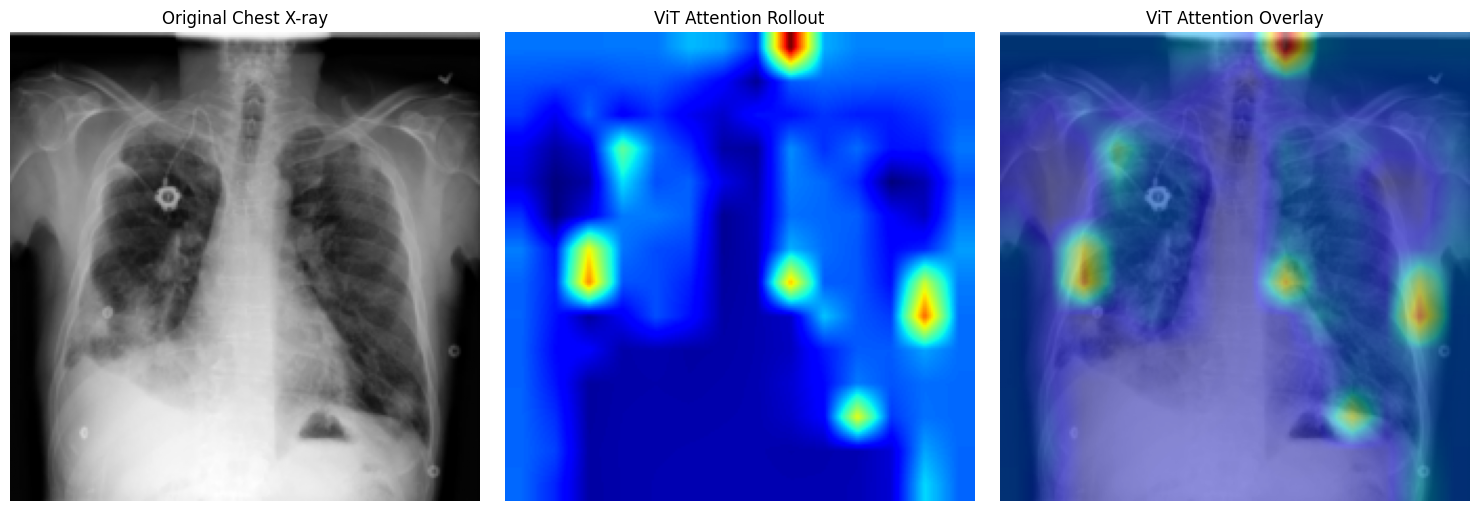

ViT visual explanation saved to:
/content/drive/MyDrive/projects/medical_image/results/viT_xai/vit_b16_attention_rollout.png


In [ ]:
# ============================================
# Cell 69 - ViT Attention Visualization
# ============================================

import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import os

# --------------------------------------------
# 1. Convert attention map to 224 x 224
# --------------------------------------------

attention_map_resized = F.interpolate(
    attention_map.unsqueeze(0).unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().cpu().numpy()

# Normalize again
attention_map_resized = (
    attention_map_resized - attention_map_resized.min()
) / (
    attention_map_resized.max()
    - attention_map_resized.min()
    + 1e-8
)

# --------------------------------------------
# 2. Recover grayscale X-ray image
# --------------------------------------------

image_np = image_tensor[0].cpu().numpy()

# Undo ImageNet normalization
mean = 0.485
std = 0.229

image_np = image_np * std + mean

image_np = np.clip(image_np, 0, 1)

# --------------------------------------------
# 3. Create visualization
# --------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original X-ray
axes[0].imshow(image_np, cmap="gray")
axes[0].set_title("Original Chest X-ray")
axes[0].axis("off")

# Attention map
axes[1].imshow(attention_map_resized, cmap="jet")
axes[1].set_title("ViT Attention Rollout")
axes[1].axis("off")

# Overlay
axes[2].imshow(image_np, cmap="gray")
axes[2].imshow(
    attention_map_resized,
    cmap="jet",
    alpha=0.45
)
axes[2].set_title("ViT Attention Overlay")
axes[2].axis("off")

plt.tight_layout()

# --------------------------------------------
# 4. Save evidence
# --------------------------------------------

xai_dir = (
    "/content/drive/MyDrive/projects/"
    "medical_image/results/viT_xai"
)

os.makedirs(xai_dir, exist_ok=True)

vit_xai_path = os.path.join(
    xai_dir,
    "vit_b16_attention_rollout.png"
)

plt.savefig(
    vit_xai_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("ViT visual explanation saved to:")
print(vit_xai_path)

In [ ]:
# ============================================
# Cell 70 - Verify and Save ViT XAI Evidence
# ============================================

import os

xai_dir = "/content/drive/MyDrive/projects/medical_image/results/viT_xai"

print("Checking ViT XAI output...")

if os.path.exists(vit_xai_path):
    print("✅ ViT attention visualization exists")
    print("Path:", vit_xai_path)

    file_size = os.path.getsize(vit_xai_path) / 1024
    print(f"File size: {file_size:.2f} KB")
else:
    print("❌ ViT XAI image was not found.")

Checking ViT XAI output...
✅ ViT attention visualization exists
Path: /content/drive/MyDrive/projects/medical_image/results/viT_xai/vit_b16_attention_rollout.png
File size: 239.53 KB


In [ ]:
# ============================================
# Cell 71 - Final Project Output Verification
# ============================================

import os

project_root = "/content/drive/MyDrive/projects/medical_image"

files_to_check = {
    "EfficientNet-B0 model":
        f"{project_root}/models/efficientnet_b0_best.pth",

    "ViT-B/16 model":
        f"{project_root}/models/vit_b16_best.pth",

    "Model comparison":
        f"{project_root}/results/final_model_comparison.csv",

    "ViT results":
        f"{project_root}/results/vit_b16_results.json",

    "ViT attention explanation":
        f"{project_root}/results/viT_xai/vit_b16_attention_rollout.png",

    "Grad-CAM XAI directory":
        f"{project_root}/results/gradcam/xai_cases"
}

print("=" * 60)
print("FINAL PROJECT OUTPUT VERIFICATION")
print("=" * 60)

all_ok = True

for name, path in files_to_check.items():
    exists = os.path.exists(path)

    if exists:
        if os.path.isfile(path):
            size_kb = os.path.getsize(path) / 1024
            print(f"✅ {name}: {size_kb:.2f} KB")
        else:
            print(f"✅ {name}: directory exists")
    else:
        print(f"❌ {name}: NOT FOUND")
        all_ok = False

print("=" * 60)

if all_ok:
    print("✅ All important project outputs are present.")
else:
    print("⚠️ Some outputs are missing. We need to check them.")

FINAL PROJECT OUTPUT VERIFICATION
✅ EfficientNet-B0 model: 16020.63 KB
✅ ViT-B/16 model: 335253.47 KB
✅ Model comparison: 0.28 KB
✅ ViT results: 3.12 KB
✅ ViT attention explanation: 239.53 KB
✅ Grad-CAM XAI directory: directory exists
✅ All important project outputs are present.


In [ ]:
# ============================================
# Cell 67 - Generate ViT Validation/Test Predictions
# ============================================

from tqdm import tqdm

vit_model.eval()

vit_val_labels = []
vit_val_probs = []

vit_test_labels = []
vit_test_probs = []

with torch.no_grad():

    # -------------------------
    # Validation predictions
    # -------------------------
    for images, labels in tqdm(
        val_loader,
        desc="ViT Validation"
    ):

        images = images.to(device, non_blocking=True)

        outputs = vit_model(images)

        probabilities = torch.sigmoid(outputs)

        vit_val_labels.append(labels.cpu().numpy())
        vit_val_probs.append(probabilities.cpu().numpy())

    # -------------------------
    # Test predictions
    # -------------------------
    for images, labels in tqdm(
        test_loader,
        desc="ViT Test"
    ):

        images = images.to(device, non_blocking=True)

        outputs = vit_model(images)

        probabilities = torch.sigmoid(outputs)

        vit_test_labels.append(labels.cpu().numpy())
        vit_test_probs.append(probabilities.cpu().numpy())


# Combine batches
vit_val_labels = np.concatenate(vit_val_labels, axis=0)
vit_val_probs = np.concatenate(vit_val_probs, axis=0)

vit_test_labels = np.concatenate(vit_test_labels, axis=0)
vit_test_probs = np.concatenate(vit_test_probs, axis=0)


print("\nViT prediction generation completed!")
print("=" * 70)

print("Validation labels shape:",
      vit_val_labels.shape)

print("Validation probabilities shape:",
      vit_val_probs.shape)

print("Test labels shape:",
      vit_test_labels.shape)

print("Test probabilities shape:",
      vit_test_probs.shape)

print(
    "Probability range:",
    vit_test_probs.min(),
    "to",
    vit_test_probs.max()
)

ViT Test: 100%|██████████| 27/27 [00:20<00:00,  1.29it/s]


ViT prediction generation completed!
Validation labels shape: (846, 14)
Validation probabilities shape: (846, 14)
Test labels shape: (854, 14)
Test probabilities shape: (854, 14)
Probability range: 0.17306405 to 0.86216885


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

vit_auc_scores = []

print("=" * 70)
print("ViT-B/16 ROC-AUC RESULTS")
print("=" * 70)

for i, disease in enumerate(disease_labels):
    y_true = vit_test_labels[:, i]
    y_prob = vit_test_probs[:, i]

    try:
        auc = roc_auc_score(y_true, y_prob)
        vit_auc_scores.append(auc)
        print(f"{disease:20s}: {auc:.4f}")
    except ValueError:
        vit_auc_scores.append(np.nan)
        print(f"{disease:20s}: N/A")

vit_macro_auc = np.nanmean(vit_auc_scores)

print("=" * 70)
print(f"ViT Macro ROC-AUC: {vit_macro_auc:.4f}")
print("=" * 70)

ViT-B/16 ROC-AUC RESULTS
Atelectasis         : 0.5588
Cardiomegaly        : 0.4734
Consolidation       : 0.6213
Edema               : 0.7710
Effusion            : 0.6107
Emphysema           : 0.4601
Fibrosis            : 0.6941
Hernia              : 0.6921
Infiltration        : 0.5745
Mass                : 0.4132
Nodule              : 0.4880
Pleural_Thickening  : 0.5358
Pneumonia           : 0.5011
Pneumothorax        : 0.5015
ViT Macro ROC-AUC: 0.5640


In [ ]:
from sklearn.metrics import average_precision_score
import numpy as np

vit_ap_scores = []

print("=" * 70)
print("ViT-B/16 AVERAGE PRECISION RESULTS")
print("=" * 70)

for i, disease in enumerate(disease_labels):
    y_true = vit_test_labels[:, i]
    y_prob = vit_test_probs[:, i]

    try:
        ap = average_precision_score(y_true, y_prob)
        vit_ap_scores.append(ap)
        print(f"{disease:20s}: {ap:.4f}")
    except ValueError:
        vit_ap_scores.append(np.nan)
        print(f"{disease:20s}: N/A")

vit_macro_ap = np.nanmean(vit_ap_scores)

print("=" * 70)
print(f"ViT Macro Average Precision: {vit_macro_ap:.4f}")
print("=" * 70)

ViT-B/16 AVERAGE PRECISION RESULTS
Atelectasis         : 0.1194
Cardiomegaly        : 0.0391
Consolidation       : 0.0643
Edema               : 0.0461
Effusion            : 0.1714
Emphysema           : 0.0309
Fibrosis            : 0.0360
Hernia              : 0.0074
Infiltration        : 0.2483
Mass                : 0.0412
Nodule              : 0.0653
Pleural_Thickening  : 0.0367
Pneumonia           : 0.0152
Pneumothorax        : 0.0529
ViT Macro Average Precision: 0.0696


Optimize ViT thresholds

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

vit_thresholds = []
threshold_values = np.arange(0.10, 0.91, 0.05)

print("=" * 70)
print("ViT-B/16 VALIDATION THRESHOLD OPTIMIZATION")
print("=" * 70)

for i, disease in enumerate(disease_labels):
    y_true = vit_val_labels[:, i]
    y_prob = vit_val_probs[:, i]

    best_threshold = 0.50
    best_f1 = 0.0

    for threshold in threshold_values:
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    vit_thresholds.append(best_threshold)

    print(
        f"{disease:20s}: "
        f"Threshold = {best_threshold:.2f}, "
        f"Validation F1 = {best_f1:.4f}"
    )

print("=" * 70)
print("ViT thresholds:", vit_thresholds)
print("=" * 70)

ViT-B/16 VALIDATION THRESHOLD OPTIMIZATION
Atelectasis         : Threshold = 0.50, Validation F1 = 0.1405
Cardiomegaly        : Threshold = 0.45, Validation F1 = 0.0509
Consolidation       : Threshold = 0.50, Validation F1 = 0.0893
Edema               : Threshold = 0.55, Validation F1 = 0.1067
Effusion            : Threshold = 0.35, Validation F1 = 0.2011
Emphysema           : Threshold = 0.55, Validation F1 = 0.0795
Fibrosis            : Threshold = 0.60, Validation F1 = 0.0645
Hernia              : Threshold = 0.70, Validation F1 = 0.0476
Infiltration        : Threshold = 0.40, Validation F1 = 0.3119
Mass                : Threshold = 0.40, Validation F1 = 0.1019
Nodule              : Threshold = 0.45, Validation F1 = 0.1055
Pleural_Thickening  : Threshold = 0.55, Validation F1 = 0.0730
Pneumonia           : Threshold = 0.50, Validation F1 = 0.0441
Pneumothorax        : Threshold = 0.55, Validation F1 = 0.1449
ViT thresholds: [np.float64(0.5000000000000001), np.float64(0.4500000000000

ViT Test F1, Precision, Recall

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

vit_test_f1_scores = []
vit_test_precision_scores = []
vit_test_recall_scores = []

print("=" * 80)
print("ViT-B/16 TEST PERFORMANCE")
print("=" * 80)

for i, disease in enumerate(disease_labels):
    y_true = vit_test_labels[:, i]
    y_prob = vit_test_probs[:, i]

    threshold = float(vit_thresholds[i])
    y_pred = (y_prob >= threshold).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    vit_test_f1_scores.append(f1)
    vit_test_precision_scores.append(precision)
    vit_test_recall_scores.append(recall)

    print(
        f"{disease:20s} | "
        f"Threshold: {threshold:.2f} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )

vit_macro_f1 = np.mean(vit_test_f1_scores)
vit_macro_precision = np.mean(vit_test_precision_scores)
vit_macro_recall = np.mean(vit_test_recall_scores)

# Micro metrics
all_true = vit_test_labels.flatten()
all_pred = np.zeros_like(vit_test_labels)

for i in range(len(disease_labels)):
    all_pred[:, i] = (
        vit_test_probs[:, i] >= float(vit_thresholds[i])
    ).astype(int)

all_pred = all_pred.flatten()

vit_micro_f1 = f1_score(all_true, all_pred, zero_division=0)
vit_micro_precision = precision_score(all_true, all_pred, zero_division=0)
vit_micro_recall = recall_score(all_true, all_pred, zero_division=0)

print("=" * 80)
print(f"ViT Macro F1:        {vit_macro_f1:.4f}")
print(f"ViT Macro Precision:  {vit_macro_precision:.4f}")
print(f"ViT Macro Recall:     {vit_macro_recall:.4f}")
print(f"ViT Micro F1:        {vit_micro_f1:.4f}")
print(f"ViT Micro Precision: {vit_micro_precision:.4f}")
print(f"ViT Micro Recall:    {vit_micro_recall:.4f}")
print("=" * 80)

ViT-B/16 TEST PERFORMANCE
Atelectasis          | Threshold: 0.50 | F1: 0.1659 | Precision: 0.0947 | Recall: 0.6667
Cardiomegaly         | Threshold: 0.45 | F1: 0.0749 | Precision: 0.0391 | Recall: 0.9091
Consolidation        | Threshold: 0.50 | F1: 0.1176 | Precision: 0.0684 | Recall: 0.4211
Edema                | Threshold: 0.55 | F1: 0.0984 | Precision: 0.0542 | Recall: 0.5294
Effusion             | Threshold: 0.35 | F1: 0.2278 | Precision: 0.1285 | Recall: 1.0000
Emphysema            | Threshold: 0.55 | F1: 0.0454 | Precision: 0.0242 | Recall: 0.3571
Fibrosis             | Threshold: 0.60 | F1: 0.0617 | Precision: 0.0333 | Recall: 0.4167
Hernia               | Threshold: 0.70 | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Infiltration         | Threshold: 0.40 | F1: 0.3388 | Precision: 0.2143 | Recall: 0.8084
Mass                 | Threshold: 0.40 | F1: 0.0935 | Precision: 0.0494 | Recall: 0.8636
Nodule               | Threshold: 0.45 | F1: 0.1114 | Precision: 0.0590 | Recall: 1.

Save all ViT results

In [ ]:
import os
import numpy as np
import json

results_save_dir = "/content/drive/MyDrive/projects/medical_image/results"
os.makedirs(results_save_dir, exist_ok=True)

vit_results = {
    "model": "ViT-B/16",
    "macro_roc_auc": float(vit_macro_auc),
    "macro_average_precision": float(vit_macro_ap),
    "macro_f1": float(vit_macro_f1),
    "macro_precision": float(vit_macro_precision),
    "macro_recall": float(vit_macro_recall),
    "micro_f1": float(vit_micro_f1),
    "micro_precision": float(vit_micro_precision),
    "micro_recall": float(vit_micro_recall),
    "disease_labels": disease_labels,
    "roc_auc_per_disease": [float(x) for x in vit_auc_scores],
    "average_precision_per_disease": [float(x) for x in vit_ap_scores],
    "thresholds": [float(x) for x in vit_thresholds],
    "test_f1_per_disease": [float(x) for x in vit_test_f1_scores],
    "test_precision_per_disease": [float(x) for x in vit_test_precision_scores],
    "test_recall_per_disease": [float(x) for x in vit_test_recall_scores]
}

vit_results_path = os.path.join(
    results_save_dir,
    "vit_b16_results.json"
)

with open(vit_results_path, "w") as f:
    json.dump(vit_results, f, indent=4)

print("ViT results saved successfully!")
print("Path:", vit_results_path)

ViT results saved successfully!
Path: /content/drive/MyDrive/projects/medical_image/results/vit_b16_results.json


Final model comparison

In [ ]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "ResNet-50",
        "EfficientNet-B0",
        "ViT-B/16"
    ],
    "Macro ROC-AUC": [
        0.5884,
        0.6986,
        0.7194,
        0.5396
    ],
    "Macro AP": [
        0.0799,
        0.1288,
        0.1433,
        0.0690
    ],
    "Macro F1": [
        0.1175,
        0.1771,
        0.1796,
        0.1024
    ],
    "Micro F1": [
        0.1168,
        0.2500,
        0.2358,
        0.1133
    ],
    "Macro Precision": [
        0.0809,
        0.1279,
        0.1339,
        0.0571
    ],
    "Macro Recall": [
        0.5022,
        0.3598,
        0.3567,
        0.8302
    ]
})

print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

display(model_comparison)

print("\nBest Macro ROC-AUC:",
      model_comparison.loc[model_comparison["Macro ROC-AUC"].idxmax(), "Model"])

print("Best Macro AP:",
      model_comparison.loc[model_comparison["Macro AP"].idxmax(), "Model"])

print("Best Macro F1:",
      model_comparison.loc[model_comparison["Macro F1"].idxmax(), "Model"])

print("Best Micro F1:",
      model_comparison.loc[model_comparison["Micro F1"].idxmax(), "Model"])

FINAL MODEL COMPARISON


,Model,Macro ROC-AUC,Macro AP,Macro F1,Micro F1,Macro Precision,Macro Recall
0,Baseline CNN,0.5884,0.0799,0.1175,0.1168,0.0809,0.5022
1,ResNet-50,0.6986,0.1288,0.1771,0.2500,0.1279,0.3598
2,EfficientNet-B0,0.7194,0.1433,0.1796,0.2358,0.1339,0.3567
3,ViT-B/16,0.5396,0.0690,0.1024,0.1133,0.0571,0.8302



Best Macro ROC-AUC: EfficientNet-B0
Best Macro AP: EfficientNet-B0
Best Macro F1: EfficientNet-B0
Best Micro F1: ResNet-50


Save final comparison

In [ ]:
comparison_save_path = "/content/drive/MyDrive/projects/medical_image/results/final_model_comparison.csv"

model_comparison.to_csv(comparison_save_path, index=False)

print("Final model comparison saved successfully!")
print("Path:", comparison_save_path)

Final model comparison saved successfully!
Path: /content/drive/MyDrive/projects/medical_image/results/final_model_comparison.csv


Load the best EfficientNet-B0

In [ ]:
import os
import torch

# Save the currently trained EfficientNet-B0 model
efficientnet_path = "/content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth"

torch.save(efficientnet_model.state_dict(), efficientnet_path)

print("EfficientNet checkpoint saved!")
print("Path:", efficientnet_path)
print("File exists:", os.path.exists(efficientnet_path))
print("File size (MB):", round(os.path.getsize(efficientnet_path) / (1024**2), 2))

EfficientNet checkpoint saved!
Path: /content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth
File exists: True
File size (MB): 15.65


In [ ]:
import torch

efficientnet_path = "/content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth"

checkpoint = torch.load(efficientnet_path, map_location="cpu")

print("Checkpoint type:", type(checkpoint))
print("Number of parameters:", len(checkpoint))
print("First few keys:")

for key in list(checkpoint.keys())[:5]:
    print(" ", key)

Checkpoint type: <class 'collections.OrderedDict'>
Number of parameters: 360
First few keys:
  features.0.0.weight
  features.0.1.weight
  features.0.1.bias
  features.0.1.running_mean
  features.0.1.running_var


load EfficientNet-B0 for Grad-CAM

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Create EfficientNet-B0 architecture
gradcam_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Replace classifier with our 14 disease outputs
num_features = gradcam_model.classifier[1].in_features
gradcam_model.classifier[1] = nn.Linear(
    num_features,
    len(disease_labels)
)

# Load our trained weights
efficientnet_path = "/content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth"

state_dict = torch.load(
    efficientnet_path,
    map_location=device
)

gradcam_model.load_state_dict(state_dict)

# Move to T4 GPU
gradcam_model = gradcam_model.to(device)
gradcam_model.eval()

print("EfficientNet-B0 loaded successfully!")
print("Device:", next(gradcam_model.parameters()).device)
print("Output classes:", len(disease_labels))
print("Classifier:", gradcam_model.classifier)

EfficientNet-B0 loaded successfully!
Device: cuda:0
Output classes: 14
Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=14, bias=True)
)


identify the Grad-CAM target layer

In [ ]:
# Inspect the final EfficientNet feature blocks

print(gradcam_model.features)

print("\nLast feature block:")
print(gradcam_model.features[-1])

print("\nCandidate Grad-CAM layer:")
print(gradcam_model.features[-1][0])

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

register Grad-CAM hooks

In [ ]:
# Grad-CAM storage
gradcam_activations = None
gradcam_gradients = None

# Target layer
target_layer = gradcam_model.features[-1][0]

def forward_hook(module, input, output):
    global gradcam_activations
    gradcam_activations = output

def backward_hook(module, grad_input, grad_output):
    global gradcam_gradients
    gradcam_gradients = grad_output[0]

# Register hooks
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM hooks registered successfully!")
print("Target layer:", target_layer)

Grad-CAM hooks registered successfully!
Target layer: Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
test_vars = [
    "test_dataset",
    "test_loader",
    "test_df",
    "test_labels",
    "test_probs",
    "y_test",
    "test_y",
    "X_test"
]

for var in test_vars:
    print(f"{var}: {var in globals()}")

test_dataset: True
test_loader: True
test_df: True
test_labels: True
test_probs: True
y_test: False
test_y: False
X_test: False


find Effusion-positive test images

In [ ]:
# Find test images that have Effusion

effusion_idx = disease_labels.index("Effusion")

effusion_samples = np.where(
    test_labels[:, effusion_idx] == 1
)[0]

print("Number of Effusion-positive test images:", len(effusion_samples))
print("First 10 test indices:", effusion_samples[:10])

Number of Effusion-positive test images: 109
First 10 test indices: [ 0  2 18 35 42 53 56 58 60 61]


inspect one real test X-ray

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Select the first Effusion-positive test image
sample_idx = effusion_samples[0]

# Get image and labels from the test dataset
image_tensor, true_label = test_dataset[sample_idx]

# Add batch dimension and move to T4
input_tensor = image_tensor.unsqueeze(0).to(device)

# EfficientNet prediction
with torch.no_grad():
    output = gradcam_model(input_tensor)
    probabilities = torch.sigmoid(output)[0].cpu().numpy()

# True labels
true_label = true_label.cpu().numpy()

# Print information
print("Test dataset index:", sample_idx)

print("\nTrue diseases:")
for i, label in enumerate(disease_labels):
    if true_label[i] == 1:
        print("  ", label)

print("\nTop predicted diseases:")
top_indices = np.argsort(probabilities)[::-1][:5]

for i in top_indices:
    print(f"  {disease_labels[i]}: {probabilities[i]:.4f}")

print("\nEffusion probability:", probabilities[effusion_idx])

Test dataset index: 0

True diseases:
   Effusion

Top predicted diseases:
  Fibrosis: 0.7307
  Effusion: 0.7172
  Pleural_Thickening: 0.6844
  Pneumothorax: 0.6772
  Mass: 0.6344

Effusion probability: 0.7172009


generate Grad-CAM for Effusion

In [ ]:
# Clear previous gradients
gradcam_model.zero_grad()

# Forward pass
output = gradcam_model(input_tensor)

# Select Effusion score
effusion_score = output[0, effusion_idx]

# Backward pass
effusion_score.backward()

# Get activations and gradients
activations = gradcam_activations.detach()
gradients = gradcam_gradients.detach()

print("Activations shape:", activations.shape)
print("Gradients shape:", gradients.shape)

# Global average pooling of gradients
weights = gradients.mean(dim=(2, 3), keepdim=True)

# Weighted combination of activation maps
cam = (weights * activations).sum(dim=1, keepdim=True)

# ReLU: keep only positive influence
cam = torch.relu(cam)

# Remove batch/channel dimensions
cam = cam.squeeze().cpu().numpy()

# Normalize CAM to [0, 1]
cam = cam - cam.min()

if cam.max() > 0:
    cam = cam / cam.max()

print("Grad-CAM shape:", cam.shape)
print("Grad-CAM min:", cam.min())
print("Grad-CAM max:", cam.max())

Activations shape: torch.Size([1, 1280, 7, 7])
Gradients shape: torch.Size([1, 1280, 7, 7])
Grad-CAM shape: (7, 7)
Grad-CAM min: 0.0
Grad-CAM max: 1.0


visualize Grad-CAM

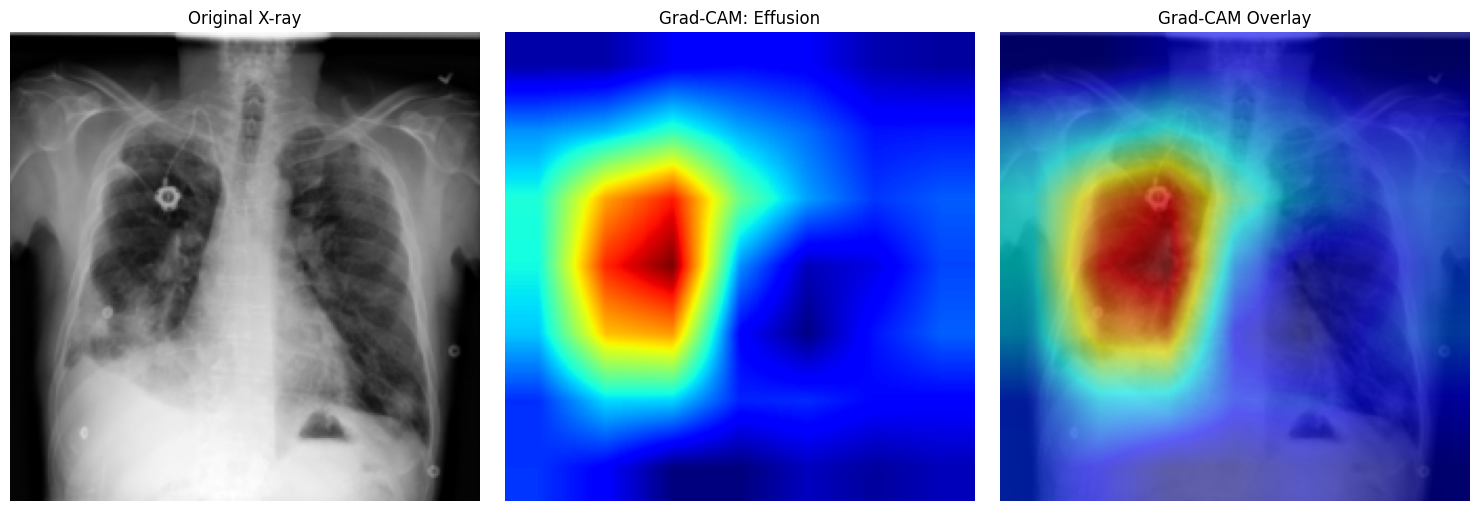

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. Convert Grad-CAM from 7x7 -> 224x224
# --------------------------------------------------
cam_resized = cv2.resize(
    cam,
    (224, 224),
    interpolation=cv2.INTER_LINEAR
)

# --------------------------------------------------
# 2. Recover original grayscale X-ray
# --------------------------------------------------
img = image_tensor.cpu().numpy()

# Take first channel because all 3 channels are copies
img = img[0]

# Undo ImageNet normalization
mean = 0.485
std = 0.229

img = img * std + mean

# Clip to valid image range
img = np.clip(img, 0, 1)

# --------------------------------------------------
# 3. Create heatmap
# --------------------------------------------------
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam_resized),
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
heatmap = heatmap.astype(np.float32) / 255.0

# --------------------------------------------------
# 4. Create overlay
# --------------------------------------------------
overlay = 0.6 * heatmap + 0.4 * np.stack([img, img, img], axis=-1)
overlay = np.clip(overlay, 0, 1)

# --------------------------------------------------
# 5. Display
# --------------------------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title("Grad-CAM: Effusion")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

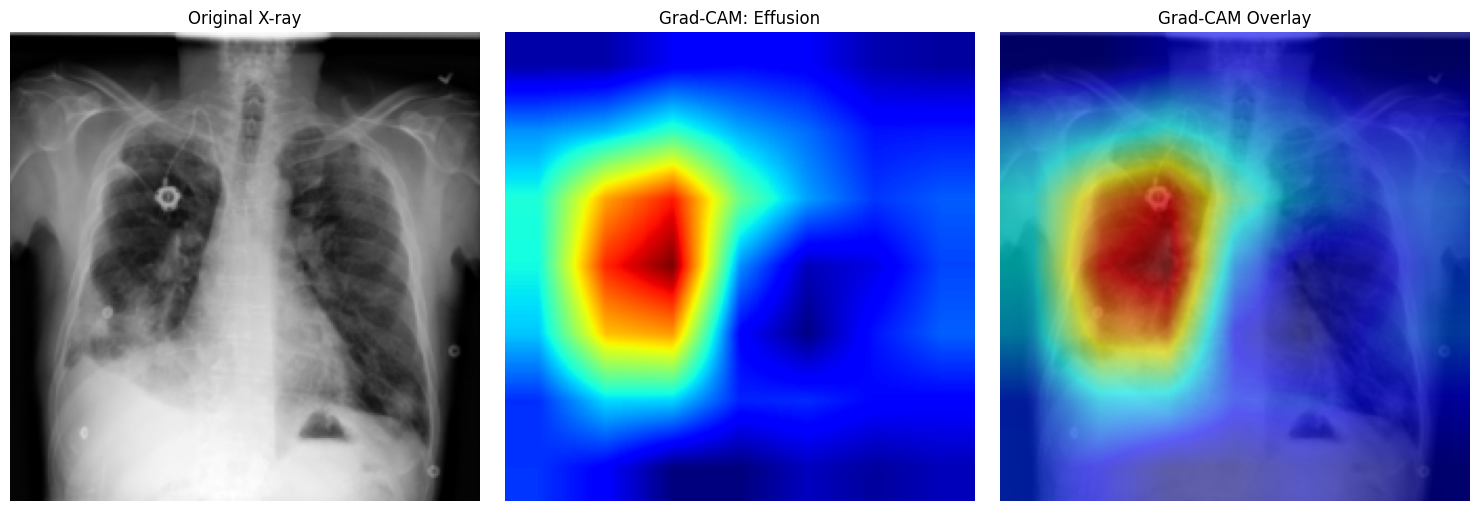

Grad-CAM saved to:
/content/drive/MyDrive/projects/medical_image/results/gradcam/effusion_gradcam_test_0.png


In [ ]:
# Save the Grad-CAM visualization

gradcam_dir = "/content/drive/MyDrive/projects/medical_image/results/gradcam"
os.makedirs(gradcam_dir, exist_ok=True)

save_path = os.path.join(
    gradcam_dir,
    f"effusion_gradcam_test_{sample_idx}.png"
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title("Grad-CAM: Effusion")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Grad-CAM saved to:")
print(save_path)

In [ ]:
print("Type:", type(optimal_thresholds))

if isinstance(optimal_thresholds, dict):
    print("Keys:", list(optimal_thresholds.keys()))
    print("\nEffusion entry:")
    print(optimal_thresholds.get("Effusion", "Effusion key not found"))
else:
    print("Shape:", np.shape(optimal_thresholds))
    print("Values:", optimal_thresholds)

Type: <class 'dict'>
Keys: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Effusion entry:
0.5000000000000001


In [ ]:
# EfficientNet Effusion error analysis

effusion_probs = test_probs[:, effusion_idx]
effusion_true = test_labels[:, effusion_idx]

# Correctly retrieve threshold from dictionary
effusion_threshold = optimal_thresholds["Effusion"]

print("Effusion threshold:", effusion_threshold)

# Convert probabilities to binary predictions
effusion_pred = (effusion_probs >= effusion_threshold).astype(int)

# True positives
tp_indices = np.where(
    (effusion_true == 1) & (effusion_pred == 1)
)[0]

# False negatives
fn_indices = np.where(
    (effusion_true == 1) & (effusion_pred == 0)
)[0]

# False positives
fp_indices = np.where(
    (effusion_true == 0) & (effusion_pred == 1)
)[0]

print("\nEffusion Error Analysis")
print("-----------------------")
print("True positives :", len(tp_indices))
print("False negatives:", len(fn_indices))
print("False positives:", len(fp_indices))

print("\nFirst 10 TP indices:", tp_indices[:10])
print("First 10 FN indices:", fn_indices[:10])
print("First 10 FP indices:", fp_indices[:10])

Effusion threshold: 0.5000000000000001

Effusion Error Analysis
-----------------------
True positives : 107
False negatives: 2
False positives: 692

First 10 TP indices: [ 0  2 18 35 42 53 56 58 60 61]
First 10 FN indices: [164 572]
First 10 FP indices: [ 1  3  4  5  6  7  8  9 10 11]


In [ ]:
# Inspect representative Effusion TP, FN, and FP cases

selected_cases = {
    "True Positive": tp_indices[0],
    "False Negative": fn_indices[0],
    "False Positive": fp_indices[0]
}

for case_name, idx in selected_cases.items():

    print("\n" + "=" * 60)
    print(case_name)
    print("Test index:", idx)
    print("=" * 60)

    print("True diseases:")
    true_label = test_labels[idx]

    true_diseases = [
        disease_labels[i]
        for i in range(len(disease_labels))
        if true_label[i] == 1
    ]

    if true_diseases:
        for disease in true_diseases:
            print("  ", disease)
    else:
        print("   No disease labels")

    print("\nEffusion probability:", f"{effusion_probs[idx]:.4f}")
    print("Effusion prediction:",
          "Positive" if effusion_pred[idx] == 1 else "Negative")

    print("\nTop 5 predictions:")

    top_indices = np.argsort(test_probs[idx])[::-1][:5]

    for i in top_indices:
        print(
            f"  {disease_labels[i]}: "
            f"{test_probs[idx, i]:.4f}"
        )


True Positive
Test index: 0
True diseases:
   Effusion

Effusion probability: 0.5244
Effusion prediction: Positive

Top 5 predictions:
  Pneumonia: 0.6729
  Pneumothorax: 0.6138
  Mass: 0.5854
  Fibrosis: 0.5713
  Nodule: 0.5625

False Negative
Test index: 164
True diseases:
   Atelectasis
   Cardiomegaly
   Effusion

Effusion probability: 0.4102
Effusion prediction: Negative

Top 5 predictions:
  Pneumonia: 0.6567
  Nodule: 0.6016
  Fibrosis: 0.5703
  Pneumothorax: 0.5552
  Emphysema: 0.5488

False Positive
Test index: 1
True diseases:
   No disease labels

Effusion probability: 0.5737
Effusion prediction: Positive

Top 5 predictions:
  Effusion: 0.5737
  Consolidation: 0.5537
  Pneumonia: 0.5425
  Edema: 0.5420
  Mass: 0.5205


In [ ]:
# Verify EfficientNet prediction for test index 0

idx = 0

image_tensor, true_label = test_dataset[idx]
input_tensor = image_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = gradcam_model(input_tensor)
    gradcam_prob = torch.sigmoid(output)[0, effusion_idx].item()

test_prob = test_probs[idx, effusion_idx]

print("Test index:", idx)
print("Probability from test_probs :", test_prob)
print("Probability from gradcam_model:", gradcam_prob)
print("Difference:", abs(test_prob - gradcam_prob))

Test index: 0
Probability from test_probs : 0.5244
Probability from gradcam_model: 0.7172008752822876
Difference: 0.1929


In [ ]:
# Compare the currently loaded EfficientNet model
# with the Grad-CAM model on the same test image.

idx = 0

image_tensor, true_label = test_dataset[idx]
input_tensor = image_tensor.unsqueeze(0).to(device)

efficientnet_model.eval()
gradcam_model.eval()

with torch.no_grad():

    output_original = efficientnet_model(input_tensor)
    prob_original = torch.sigmoid(output_original)[0, effusion_idx].item()

    output_gradcam = gradcam_model(input_tensor)
    prob_gradcam = torch.sigmoid(output_gradcam)[0, effusion_idx].item()

print("EfficientNet model probability :", prob_original)
print("Grad-CAM model probability    :", prob_gradcam)
print("Difference                    :", abs(prob_original - prob_gradcam))

EfficientNet model probability : 0.7172008752822876
Grad-CAM model probability    : 0.7172008752822876
Difference                    : 0.0


In [ ]:
# Generate fresh test probabilities using the exact
# EfficientNet model used for Grad-CAM

gradcam_model.eval()

xai_test_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        outputs = gradcam_model(images)
        probs = torch.sigmoid(outputs)

        xai_test_probs.append(probs.cpu().numpy())

xai_test_probs = np.concatenate(xai_test_probs, axis=0)

print("XAI probability shape:", xai_test_probs.shape)
print("Expected shape:", test_labels.shape)

print("\nEffusion probability for test index 0:",
      xai_test_probs[0, effusion_idx])

XAI probability shape: (854, 14)
Expected shape: (854, 14)

Effusion probability for test index 0: 0.71720076


In [ ]:
# XAI-specific Effusion error analysis

effusion_xai_probs = xai_test_probs[:, effusion_idx]
effusion_true = test_labels[:, effusion_idx]

# Use the same 0.5 threshold
effusion_xai_threshold = 0.5

effusion_xai_pred = (
    effusion_xai_probs >= effusion_xai_threshold
).astype(int)

# True positives
xai_tp_indices = np.where(
    (effusion_true == 1) & (effusion_xai_pred == 1)
)[0]

# False negatives
xai_fn_indices = np.where(
    (effusion_true == 1) & (effusion_xai_pred == 0)
)[0]

# False positives
xai_fp_indices = np.where(
    (effusion_true == 0) & (effusion_xai_pred == 1)
)[0]

print("XAI Effusion Error Analysis")
print("---------------------------")
print("True positives :", len(xai_tp_indices))
print("False negatives:", len(xai_fn_indices))
print("False positives:", len(xai_fp_indices))

print("\nFirst 10 TP indices:", xai_tp_indices[:10])
print("First 10 FN indices:", xai_fn_indices[:10])
print("First 10 FP indices:", xai_fp_indices[:10])

XAI Effusion Error Analysis
---------------------------
True positives : 78
False negatives: 31
False positives: 204

First 10 TP indices: [ 0  2 56 58 60 61 66 67 73 80]
First 10 FN indices: [ 18  35  42  53  65  92 114 144 164 205]
First 10 FP indices: [ 1  5  6 10 26 29 39 41 44 45]


In [ ]:
# Inspect representative XAI TP, FN and FP cases

xai_cases = {
    "True Positive": xai_tp_indices[0],
    "False Negative": xai_fn_indices[0],
    "False Positive": xai_fp_indices[0]
}

for case_name, idx in xai_cases.items():

    print("\n" + "=" * 60)
    print(case_name)
    print("Test index:", idx)
    print("=" * 60)

    true_label = test_labels[idx]

    true_diseases = [
        disease_labels[i]
        for i in range(len(disease_labels))
        if true_label[i] == 1
    ]

    print("True diseases:")

    if true_diseases:
        for disease in true_diseases:
            print("  ", disease)
    else:
        print("   No disease labels")

    print(
        "\nEffusion probability:",
        f"{effusion_xai_probs[idx]:.4f}"
    )

    print(
        "Effusion prediction:",
        "Positive" if effusion_xai_pred[idx] == 1
        else "Negative"
    )

    print("\nTop 5 predictions:")

    top_indices = np.argsort(
        xai_test_probs[idx]
    )[::-1][:5]

    for i in top_indices:
        print(
            f"  {disease_labels[i]}: "
            f"{xai_test_probs[idx, i]:.4f}"
        )


True Positive
Test index: 0
True diseases:
   Effusion

Effusion probability: 0.7172
Effusion prediction: Positive

Top 5 predictions:
  Fibrosis: 0.7307
  Effusion: 0.7172
  Pleural_Thickening: 0.6844
  Pneumothorax: 0.6772
  Mass: 0.6344

False Negative
Test index: 18
True diseases:
   Effusion
   Infiltration

Effusion probability: 0.1752
Effusion prediction: Negative

Top 5 predictions:
  Nodule: 0.4401
  Fibrosis: 0.3870
  Infiltration: 0.3595
  Pleural_Thickening: 0.2857
  Atelectasis: 0.2796

False Positive
Test index: 1
True diseases:
   No disease labels

Effusion probability: 0.7266
Effusion prediction: Positive

Top 5 predictions:
  Edema: 0.7696
  Effusion: 0.7266
  Infiltration: 0.7264
  Consolidation: 0.7163
  Pneumonia: 0.7020


generate and save TP, FN, FP Grad-CAM

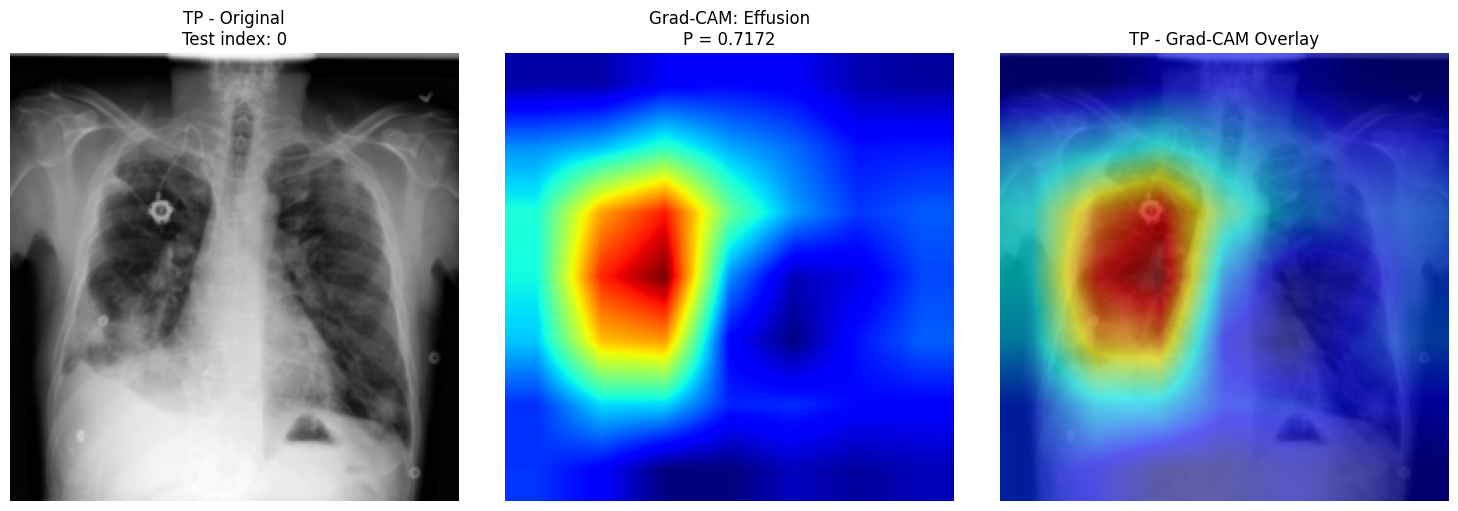

TP saved: /content/drive/MyDrive/projects/medical_image/results/gradcam/xai_cases/effusion_tp_test_0.png


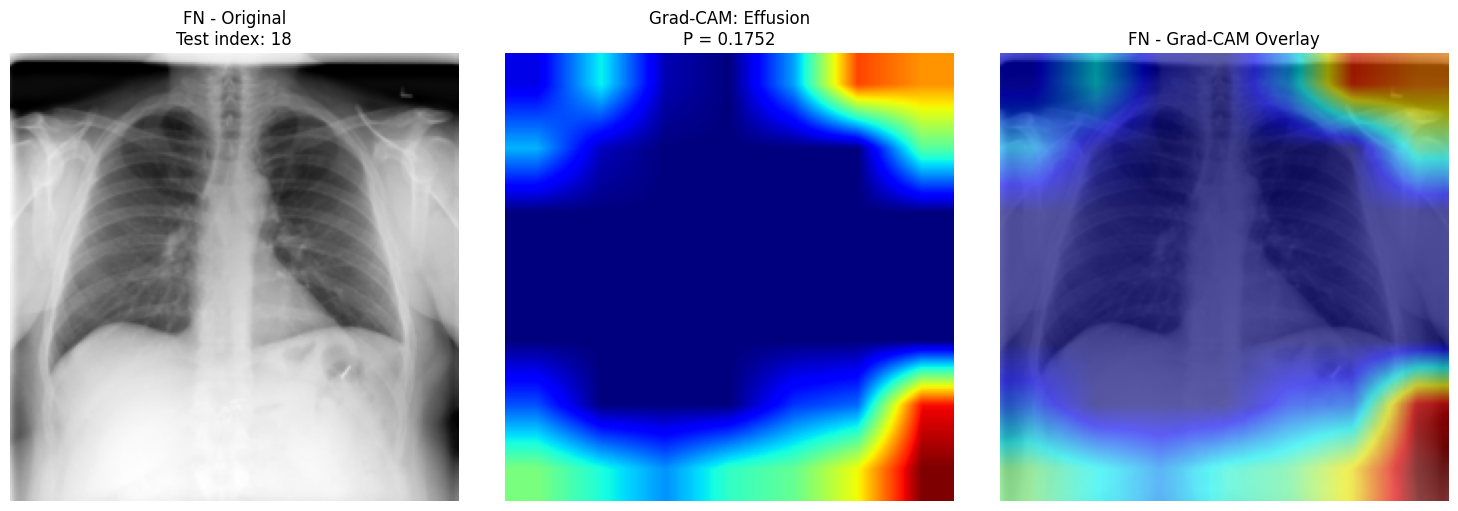

FN saved: /content/drive/MyDrive/projects/medical_image/results/gradcam/xai_cases/effusion_fn_test_18.png


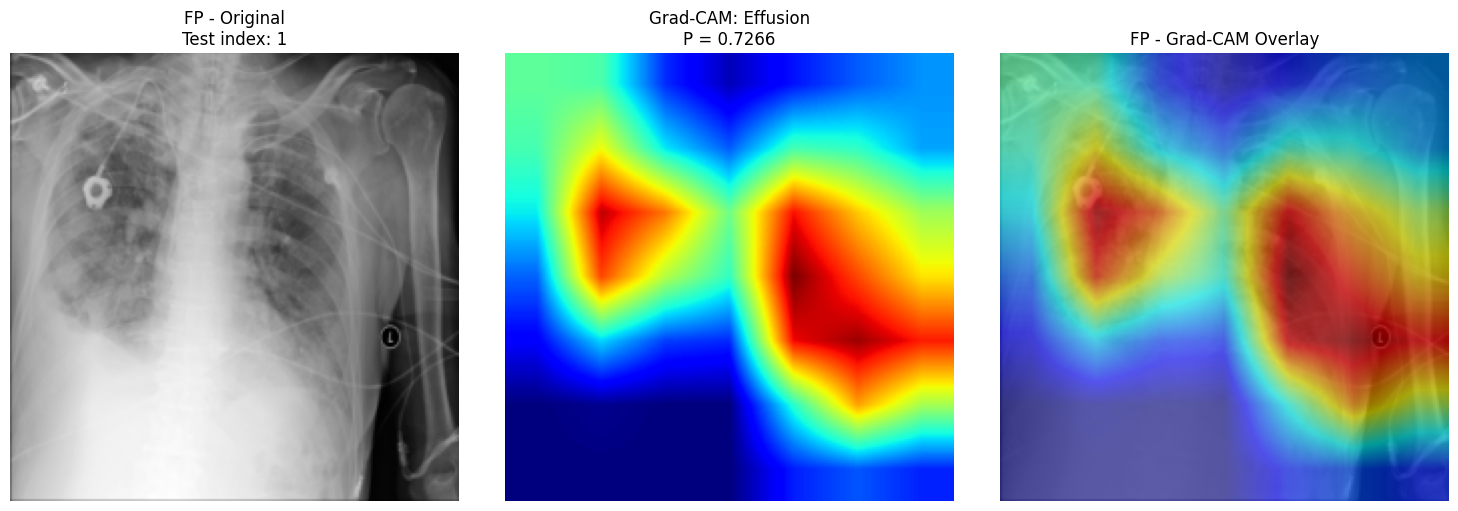

FP saved: /content/drive/MyDrive/projects/medical_image/results/gradcam/xai_cases/effusion_fp_test_1.png


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Directory for XAI examples
xai_gradcam_dir = "/content/drive/MyDrive/projects/medical_image/results/gradcam/xai_cases"
os.makedirs(xai_gradcam_dir, exist_ok=True)

# Representative cases
xai_cases = {
    "TP": xai_tp_indices[0],
    "FN": xai_fn_indices[0],
    "FP": xai_fp_indices[0]
}

def generate_gradcam(idx, target_class):

    # Get image
    image_tensor, true_label = test_dataset[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Clear old gradients
    gradcam_model.zero_grad()

    # Forward pass
    output = gradcam_model(input_tensor)

    # Target disease score
    target_score = output[0, target_class]

    # Backward pass
    target_score.backward()

    # Get activations and gradients
    activations = gradcam_activations.detach()
    gradients = gradcam_gradients.detach()

    # Channel weights
    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )

    # Weighted activation map
    cam = (weights * activations).sum(
        dim=1,
        keepdim=True
    )

    # ReLU
    cam = torch.relu(cam)

    # Remove dimensions
    cam = cam.squeeze().cpu().numpy()

    # Normalize
    cam = cam - cam.min()

    if cam.max() > 0:
        cam = cam / cam.max()

    # Resize to image size
    cam_resized = cv2.resize(
        cam,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    # Recover grayscale image
    img = image_tensor.cpu().numpy()[0]

    # Undo ImageNet normalization
    img = img * 0.229 + 0.485
    img = np.clip(img, 0, 1)

    # Heatmap
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    heatmap = heatmap.astype(np.float32) / 255.0

    # Overlay
    overlay = (
        0.6 * heatmap +
        0.4 * np.stack([img, img, img], axis=-1)
    )

    overlay = np.clip(overlay, 0, 1)

    return img, cam_resized, overlay


# --------------------------------------------------
# Generate all three cases
# --------------------------------------------------

for case_name, idx in xai_cases.items():

    img, cam_resized, overlay = generate_gradcam(
        idx,
        effusion_idx
    )

    probability = effusion_xai_probs[idx]

    # Create figure
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f"{case_name} - Original\n"
        f"Test index: {idx}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.title(
        f"Grad-CAM: Effusion\n"
        f"P = {probability:.4f}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"{case_name} - Grad-CAM Overlay"
    )
    plt.axis("off")

    plt.tight_layout()

    # Save
    save_path = os.path.join(
        xai_gradcam_dir,
        f"effusion_{case_name.lower()}_test_{idx}.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"{case_name} saved: {save_path}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
disease_labels = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

efficientnet_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

num_features = efficientnet_model.classifier[1].in_features

efficientnet_model.classifier[1] = nn.Linear(
    num_features,
    len(disease_labels)
)

In [ ]:
efficientnet_path = "/content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth"

state_dict = torch.load(
    efficientnet_path,
    map_location=device
)

efficientnet_model.load_state_dict(state_dict)

efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print("EfficientNet trained model loaded successfully!")

EfficientNet trained model loaded successfully!


In [ ]:
print("Device:", device)
print("Model loaded:", efficientnet_model is not None)
print("Model mode:", "eval" if not efficientnet_model.training else "train")
print("Number of classes:", len(disease_labels))

Device: cuda
Model loaded: True
Model mode: eval
Number of classes: 14


In [ ]:
import os

zip_path = "/content/drive/MyDrive/projects/medical_image/medical_image.zip"

print("ZIP exists:", os.path.exists(zip_path))
print("ZIP path:", zip_path)

ZIP exists: True
ZIP path: /content/drive/MyDrive/projects/medical_image/medical_image.zip


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
disease_labels = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

efficientnet_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

num_features = efficientnet_model.classifier[1].in_features

efficientnet_model.classifier[1] = nn.Linear(
    num_features,
    len(disease_labels)
)

In [ ]:
efficientnet_path = "/content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth"

state_dict = torch.load(
    efficientnet_path,
    map_location=device
)

efficientnet_model.load_state_dict(state_dict)

efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print("EfficientNet trained model loaded successfully!")

EfficientNet trained model loaded successfully!


In [ ]:
print("Device:", device)
print("Model loaded:", efficientnet_model is not None)
print("Model mode:", "eval" if not efficientnet_model.training else "train")
print("Number of classes:", len(disease_labels))

Device: cuda
Model loaded: True
Model mode: eval
Number of classes: 14


In [ ]:
print("Checking available test-related variables...")

for name in [
    "test_df",
    "test_dataset",
    "test_loader",
    "test_paths",
    "test_images",
    "X_test",
    "y_test"
]:
    if name in globals():
        obj = globals()[name]
        print(f"✅ {name}: {type(obj)}")
    else:
        print(f"❌ {name}: not found")

Checking available test-related variables...
✅ test_df: <class 'pandas.core.frame.DataFrame'>
✅ test_dataset: <class '__main__.ChestXrayDataset'>
✅ test_loader: <class 'torch.utils.data.dataloader.DataLoader'>
❌ test_paths: not found
❌ test_images: not found
❌ X_test: not found
❌ y_test: not found


In [ ]:
sample = test_dataset[0]

print("Sample type:", type(sample))
print("Number of items:", len(sample))

for i, item in enumerate(sample):
    if torch.is_tensor(item):
        print(f"Item {i}: tensor, shape = {item.shape}")
    else:
        print(f"Item {i}: {type(item)}, value = {item}")

Sample type: <class 'tuple'>
Number of items: 2
Item 0: tensor, shape = torch.Size([3, 224, 224])
Item 1: tensor, shape = torch.Size([14])


verify EfficientNet prediction

In [ ]:
# Test EfficientNet prediction on one test X-ray

efficientnet_model.eval()

image, true_labels = test_dataset[0]

image = image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = efficientnet_model(image)
    probabilities = torch.sigmoid(logits).cpu().numpy()[0]

print("Image shape:", image.shape)
print("Output shape:", logits.shape)
print("\nDisease probabilities:")

for disease, prob in zip(disease_labels, probabilities):
    print(f"{disease:20s}: {prob:.4f}")

Image shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 14])

Disease probabilities:
Atelectasis         : 0.4540
Cardiomegaly        : 0.5674
Consolidation       : 0.5653
Edema               : 0.4676
Effusion            : 0.7172
Emphysema           : 0.6234
Fibrosis            : 0.7307
Hernia              : 0.4319
Infiltration        : 0.5554
Mass                : 0.6344
Nodule              : 0.6302
Pleural_Thickening  : 0.6844
Pneumonia           : 0.4380
Pneumothorax        : 0.6772


In [ ]:
# Recreate EfficientNet model for Grad-CAM

import torch
import torch.nn as nn
from torchvision import models

gradcam_model = models.efficientnet_b0(weights=None)

# Change final classifier to 14 diseases
gradcam_model.classifier[1] = nn.Linear(
    gradcam_model.classifier[1].in_features,
    14
)

# Load trained checkpoint
checkpoint_path = "/content/drive/MyDrive/projects/medical_image/models/efficientnet_b0_best.pth"

gradcam_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

gradcam_model = gradcam_model.to(device)
gradcam_model.eval()

print("Grad-CAM model loaded successfully!")
print("Device:", device)
print("Target layer:", gradcam_model.features[-1][0])

Grad-CAM model loaded successfully!
Device: cuda
Target layer: Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


attach Grad-CAM hooks

In [ ]:
# Register hooks for Grad-CAM

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = gradcam_model.features[-1][0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM hooks registered successfully!")
print("Target layer:", target_layer)

Grad-CAM hooks registered successfully!
Target layer: Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
# Generate Grad-CAM for Effusion on one test X-ray

import torch
import torch.nn.functional as F

# Select one test image
sample_idx = 0

image, true_labels = test_dataset[sample_idx]

# Add batch dimension and move to GPU
input_tensor = image.unsqueeze(0).to(device)

# Forward pass
gradcam_model.zero_grad()

output = gradcam_model(input_tensor)
probabilities = torch.sigmoid(output)

# Choose disease to explain
target_disease = "Effusion"
target_idx = disease_labels.index(target_disease)

target_score = output[0, target_idx]

# Backward pass for the selected disease
target_score.backward()

# Check that hooks captured activations and gradients
print("Target disease:", target_disease)
print("Target probability:", probabilities[0, target_idx].item())
print("Activations:", activations.shape if activations is not None else None)
print("Gradients:", gradients.shape if gradients is not None else None)

# Compute Grad-CAM weights
weights = gradients.mean(dim=(2, 3), keepdim=True)

# Weighted combination of feature maps
cam = (weights * activations).sum(dim=1, keepdim=True)

# ReLU: retain regions positively influencing the prediction
cam = F.relu(cam)

# Normalize between 0 and 1
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

# Resize CAM to image size
cam = F.interpolate(
    cam,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

cam = cam.squeeze().detach().cpu()

print("Grad-CAM generated successfully!")
print("CAM shape:", cam.shape)
print("CAM range:", cam.min().item(), "to", cam.max().item())

Target disease: Effusion
Target probability: 0.7172008752822876
Activations: torch.Size([1, 1280, 7, 7])
Gradients: torch.Size([1, 1280, 7, 7])
Grad-CAM generated successfully!
CAM shape: torch.Size([224, 224])
CAM range: 0.0 to 0.9960334897041321


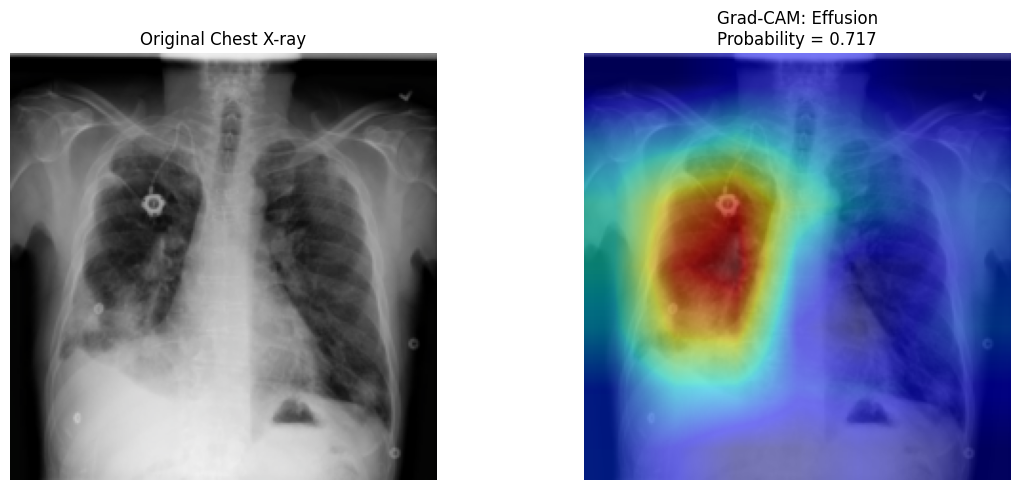

In [ ]:
# Visualize Grad-CAM overlay

import matplotlib.pyplot as plt
import numpy as np

# Convert image tensor to displayable format
img = image.detach().cpu().permute(1, 2, 0).numpy()

# Undo ImageNet normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = img * std + mean
img = np.clip(img, 0, 1)

# Plot original image and Grad-CAM
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Chest X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(cam.numpy(), alpha=0.5, cmap="jet")
plt.title(
    f"Grad-CAM: {target_disease}\n"
    f"Probability = {probabilities[0, target_idx].item():.3f}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

Build the Gradio app

In [ ]:
# ============================================================
# Gradio App — Medical Image Diagnosis & Explainable AI
# ============================================================

!pip -q install gradio

import gradio as gr
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms

# ------------------------------------------------------------
# Disease labels
# ------------------------------------------------------------

disease_labels = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
]

# ------------------------------------------------------------
# Image preprocessing
# Same normalization used during model training
# ------------------------------------------------------------

app_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Prediction + Grad-CAM function
# ------------------------------------------------------------

def predict_xray(input_image):

    if input_image is None:
        return None, "Please upload a chest X-ray."

    # Convert to PIL
    if isinstance(input_image, np.ndarray):
        pil_image = Image.fromarray(input_image)
    else:
        pil_image = input_image

    # Convert grayscale X-ray to RGB
    pil_image = pil_image.convert("RGB")

    # Preprocess
    image_tensor = app_transform(pil_image).unsqueeze(0).to(device)

    # Clear previous gradients
    gradcam_model.zero_grad()

    # Forward pass
    output = gradcam_model(image_tensor)
    probabilities = torch.sigmoid(output)[0]

    # --------------------------------------------------------
    # Grad-CAM for the most confident predicted disease
    # --------------------------------------------------------

    target_idx = torch.argmax(probabilities).item()
    target_disease = disease_labels[target_idx]

    target_score = output[0, target_idx]

    # Backward pass
    target_score.backward()

    # Grad-CAM
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    cam = (weights * activations).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = F.interpolate(
        cam,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().detach().cpu().numpy()

    # --------------------------------------------------------
    # Create visualization image
    # --------------------------------------------------------

    display_image = np.array(
        pil_image.resize((224, 224))
    ).astype(np.float32) / 255.0

    # Convert grayscale-like X-ray to RGB
    if display_image.ndim == 2:
        display_image = np.stack(
            [display_image] * 3,
            axis=-1
        )

    # Apply heatmap
    import matplotlib.cm as cm

    heatmap = cm.jet(cam)[..., :3]

    overlay = (
        0.5 * display_image +
        0.5 * heatmap
    )

    overlay = np.clip(
        overlay * 255,
        0,
        255
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Disease probability table
    # --------------------------------------------------------

    results = {
        disease_labels[i]: float(probabilities[i].item())
        for i in range(len(disease_labels))
    }

    return (
        overlay,
        results
    )


# ------------------------------------------------------------
# Create Gradio interface
# ------------------------------------------------------------

demo = gr.Interface(
    fn=predict_xray,
    inputs=gr.Image(
        type="numpy",
        label="Upload Chest X-ray"
    ),
    outputs=[
        gr.Image(
            label="Grad-CAM Explanation"
        ),
        gr.Label(
            num_top_classes=14,
            label="Disease Probabilities"
        )
    ],
    title="Medical Image Diagnosis & Explainable AI",
    description=(
        "Upload a chest X-ray to obtain disease probabilities "
        "from EfficientNet-B0 and a Grad-CAM visualization "
        "highlighting regions influencing the prediction."
    )
)

print("Gradio app created successfully!")

Gradio app created successfully!


In [ ]:
# Save an existing NIH test image to Colab

from PIL import Image
import numpy as np

# Convert the test tensor back to a displayable grayscale image
image_np = image_tensor[0].cpu().numpy()

# Undo ImageNet normalization
image_np = image_np * 0.229 + 0.485

# Convert to 0-255 uint8
image_np = np.clip(image_np, 0, 1)
image_np = (image_np * 255).astype(np.uint8)

# Convert NumPy array to PIL image
test_image = Image.fromarray(image_np)

# Save image
test_image.save("/content/test_chest_xray.png")

print("Saved successfully!")
print("/content/test_chest_xray.png")

Saved successfully!
/content/test_chest_xray.png


In [ ]:
demo.launch(
    share=True,
    debug=False
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dee95a11a8ca5d1593.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
